# Analysis of climate impact on house prices

In [109]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels as sm
import statsmodels.formula.api as smf
from patsy import dmatrices
import re
from scipy import stats
import geopandas as gpd
import matplotlib.patches as mpatches
from pathlib import Path
import warnings
from joblib import dump
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

In [110]:
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")
sns.set_theme(style='whitegrid', context='talk')

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent

ECONOMIC_DIR = ROOT / 'data' / 'economic'
POPULATION_DIR = ROOT / 'data' / 'population'
LAST_COMPLETE_YEAR = pd.Timestamp.today().year - 1
TARGET_YEARS = list(range(LAST_COMPLETE_YEAR - 9, LAST_COMPLETE_YEAR + 1))
TARGET_YEARS

[2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

## Load and Transform Data

In [111]:
# Load data into pd DataFrames
natural_disasters_df = pd.read_csv(r"..\data\climate\FEMA_Disaster_Declarations.csv")
nri_county_df = pd.read_csv(r"..\data\climate\NRI_Table_Counties.csv")
housing_county_df = pd.read_csv(r"..\data\housing\Redfin-Housing-Market-By-County.csv")
fips_df = pd.read_csv(r"..\data\geographic\fips_master_v2.csv")
personal_income_df = pd.read_csv(
    r"..\data\economic\BEA - US, States, Counties - Personal Income.csv",
    usecols=["IBRC_GEO_ID", "Year", "Data", "Linecode Description"],
    low_memory=False,
)

nri_county_df = (
    nri_county_df.assign(
        fips = nri_county_df["STCOFIPS"].astype(str).str.zfill(5),
        nri_risk_score = pd.to_numeric(nri_county_df["RISK_SCORE"], errors = "coerce"),
        nri_risk_rating = nri_county_df["RISK_RATNG"],
        nri_risk_rating_date = nri_county_df["NRI_VER"]
    )[["fips", "nri_risk_score", "nri_risk_rating", "nri_risk_rating_date"]]
    .drop_duplicates(subset = ["fips"])
)


### Economic and Demographic data


#### Paths

The notebook reads the exact files requested in the task. The economic filename in the prompt contains a typo; the file on disk is `CEW - US, States, Counties - Total Ownership.csv`.


In [112]:

bea_income_path = ECONOMIC_DIR / 'BEA - US, States, Counties - Personal Income.csv'
cew_total_path = ECONOMIC_DIR / 'CEW - US, States, Counties - Total Ownership.csv'
pop_change_path = POPULATION_DIR / 'Components of Population Change - U.S., States, and Counties.csv'
pop_age_sex_path = POPULATION_DIR / 'Population by Age and Sex - US, States, Counties.csv'
pop_race_path = POPULATION_DIR / 'Population by Race - US, States, Counties.csv'
pop_estimates_path = POPULATION_DIR / 'Population Estimates - U.S., States, and Counties.csv'

for path in [
    bea_income_path,
    cew_total_path,
    pop_change_path,
    pop_age_sex_path,
    pop_race_path,
    pop_estimates_path,
]:
    print(path.relative_to(ROOT))


data\economic\BEA - US, States, Counties - Personal Income.csv
data\economic\CEW - US, States, Counties - Total Ownership.csv
data\population\Components of Population Change - U.S., States, and Counties.csv
data\population\Population by Age and Sex - US, States, Counties.csv
data\population\Population by Race - US, States, Counties.csv
data\population\Population Estimates - U.S., States, and Counties.csv


In [113]:

BEA_LINECODES = {
    10: 'personal_income',
    30: 'per_capita_income',
    46: 'dividends_interest_rent',
    47: 'transfer_receipts',
    70: 'proprietors_income',
}

FEATURE_LABELS = {
    'log_population': 'Population size',
    'per_capita_income': 'Per capita income',
    'employment_rate_proxy': 'Employment per resident',
    'Average Weekly Wage': 'Average weekly wage',
    'transfer_receipts_share': 'Transfer receipts share',
    'dividends_rent_share': 'Dividends, interest, and rent share',
    'proprietors_income_share': 'Proprietors income share',
    'youth_share': 'Youth share',
    'prime_working_age_share': 'Prime working-age share',
    'senior_share': 'Senior share',
    'male_share': 'Male share',
    'white_share': 'White share',
    'black_share': 'Black share',
    'asian_share': 'Asian share',
    'hispanic_share': 'Hispanic share',
    'natural_increase_rate': 'Natural increase rate',
    'international_migration_rate': 'International migration rate',
    'domestic_migration_rate': 'Domestic migration rate',
}

FEATURE_COLUMNS = list(FEATURE_LABELS)


def add_county_fips(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['Statefips'] = pd.to_numeric(out['Statefips'], errors='coerce')
    out['Countyfips'] = pd.to_numeric(out['Countyfips'], errors='coerce')
    out = out.dropna(subset=['Statefips', 'Countyfips'])
    out['state_fips'] = out['Statefips'].astype(int).astype(str).str.zfill(2)
    out['county_fips'] = out['Countyfips'].astype(int).astype(str).str.zfill(3)
    out = out[(out['state_fips'] != '00') & (out['county_fips'] != '000')].copy()
    out['fips'] = out['state_fips'] + out['county_fips']
    return out


def dedupe_by_key(df: pd.DataFrame, key_cols: list[str], strategy: str = 'first') -> pd.DataFrame:
    if not df.duplicated(key_cols).any():
        return df

    if strategy == 'largest_magnitude':
        numeric_cols = [
            col for col in df.columns
            if col not in key_cols and pd.api.types.is_numeric_dtype(df[col])
        ]
        score = df[numeric_cols].fillna(0).abs().sum(axis=1)
        return (
            df.assign(_score=score)
              .sort_values(key_cols + ['_score'], ascending=[True] * len(key_cols) + [False])
              .drop_duplicates(key_cols)
              .drop(columns='_score')
        )

    if strategy == 'count_over_estimate':
        rank = df['Count or Estimate'].map({'Count': 0, 'Estimate': 1}).fillna(2)
        return (
            df.assign(_rank=rank)
              .sort_values(key_cols + ['_rank'])
              .drop_duplicates(key_cols)
              .drop(columns='_rank')
        )

    return df.sort_values(key_cols).drop_duplicates(key_cols)


def build_latest_available_panel(df: pd.DataFrame, value_cols: list[str], years: list[int]) -> pd.DataFrame:
    df = df[['fips', 'Year'] + value_cols].sort_values(['fips', 'Year']).drop_duplicates(['fips', 'Year'])
    idx = pd.MultiIndex.from_product(
        [df['fips'].unique(), range(int(df['Year'].min()), years[-1] + 1)],
        names=['fips', 'Year'],
    )
    out = df.set_index(['fips', 'Year']).reindex(idx)
    out = out.groupby(level=0).ffill().groupby(level=0).bfill().reset_index()
    return out[out['Year'].isin(years)].copy()


def read_cew_totals(path: Path, chunksize: int = 500_000) -> pd.DataFrame:
    chunks = []
    for chunk in pd.read_csv(
        path,
        usecols=[
            'Statefips', 'Countyfips', 'Description', 'Year', 'Ownership Code',
            'NAICS Code', 'Employment', 'Wages', 'Average Wage', 'Average Weekly Wage'
        ],
        chunksize=chunksize,
        low_memory=False,
    ):
        chunk['Ownership Code'] = pd.to_numeric(chunk['Ownership Code'], errors='coerce')
        chunk['NAICS Code'] = pd.to_numeric(chunk['NAICS Code'], errors='coerce')
        chunk = chunk[(chunk['Ownership Code'] == 0) & (chunk['NAICS Code'] == 0)]
        chunk = add_county_fips(chunk)
        chunks.append(chunk)

    out = pd.concat(chunks, ignore_index=True)
    out = out[[
        'fips', 'Description', 'Year', 'Employment', 'Wages',
        'Average Wage', 'Average Weekly Wage'
    ]]
    return dedupe_by_key(out, ['fips', 'Year'])


def summarize_cluster(z_scores: pd.Series, county_count: int) -> str:
    high = z_scores.sort_values(ascending=False).head(3)
    low = z_scores.sort_values().head(3)

    def phrase(feature: str, value: float) -> str:
        label = FEATURE_LABELS[feature]
        direction = 'above' if value > 0 else 'below'
        return f"{label} ({abs(value):.1f} SD {direction} average)"

    high_text = '; '.join(phrase(feature, value) for feature, value in high.items())
    low_text = '; '.join(phrase(feature, value) for feature, value in low.items())
    return (
        f"This cluster contains {county_count:,} counties. "
        f"It is distinguished by {high_text}. "
        f"It is relatively low on {low_text}."
    )


#### Read the Requested CSV Files Into Individual DataFrames

In [114]:

bea_income_raw = pd.read_csv(
    bea_income_path,
    usecols=['Statefips', 'Countyfips', 'Description', 'Year', 'Linecode', 'Linecode Description', 'Data'],
    low_memory=False,
)
bea_income_df = add_county_fips(bea_income_raw)
bea_income_df = bea_income_df[bea_income_df['Linecode'].isin(BEA_LINECODES)].copy()
bea_income_df['metric'] = bea_income_df['Linecode'].map(BEA_LINECODES)

cew_total_df = read_cew_totals(cew_total_path)

population_change_df = pd.read_csv(pop_change_path, low_memory=False)
population_change_df = add_county_fips(population_change_df)
population_change_df = dedupe_by_key(population_change_df, ['fips', 'Year'], strategy='largest_magnitude')

population_age_sex_df = pd.read_csv(pop_age_sex_path, low_memory=False)
population_age_sex_df = add_county_fips(population_age_sex_df)
population_age_sex_df = dedupe_by_key(population_age_sex_df, ['fips', 'Year'])

population_race_df = pd.read_csv(pop_race_path, low_memory=False)
population_race_df = add_county_fips(population_race_df)
population_race_df = dedupe_by_key(population_race_df, ['fips', 'Year'])

population_estimates_df = pd.read_csv(pop_estimates_path, low_memory=False)
population_estimates_df = add_county_fips(population_estimates_df)
population_estimates_df = population_estimates_df[
    population_estimates_df['State or County Release'].eq('County')
].copy()
population_estimates_df = dedupe_by_key(
    population_estimates_df,
    ['fips', 'Year'],
    strategy='count_over_estimate',
)

for name, df in {
    'bea_income_df': bea_income_df,
    'cew_total_df': cew_total_df,
    'population_change_df': population_change_df,
    'population_age_sex_df': population_age_sex_df,
    'population_race_df': population_race_df,
    'population_estimates_df': population_estimates_df,
}.items():
    print(f"{name:24s} rows={len(df):>9,} counties={df['fips'].nunique():>5,} years={int(df['Year'].min())}-{int(df['Year'].max())}")


bea_income_df            rows=  339,365 counties=1,406 years=2001-2023
cew_total_df             rows=   34,283 counties=1,444 years=2001-2024
population_change_df     rows=  113,950 counties=3,158 years=1981-2025
population_age_sex_df    rows=   78,575 counties=3,156 years=2000-2024
population_race_df       rows=  109,970 counties=3,158 years=1990-2024
population_estimates_df  rows=   91,145 counties=3,158 years=1970-2025


### FIPS code data

#### Cleaning and Preprocessing

In [115]:
# For county FIPS codes

# Strip trailing and leading whitespaces from all values
fips_df = fips_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Convert fips from int to 5-digit str, padded with zeroes to the left
fips_df['fips'] = (
    fips_df['fips']
        .astype('str')
        .str.zfill(5)
)

# Hawaii's county master combines Maui and Kalawao under 15009, but FEMA emits
# a separate 15005 county code for Kalawao. Add a county-level alias from the
# existing Hawaii reference row so disaster joins can resolve both codes.
kalawao_alias = fips_df.loc[fips_df['fips'] == '15009'].copy()
kalawao_alias['fips'] = '15005'
kalawao_alias['county_name'] = 'Kalawao County'
fips_df = pd.concat([fips_df, kalawao_alias], ignore_index=True)

fips_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3219 entries, 0 to 3218
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   fips         3219 non-null   str  
 1   county_name  3168 non-null   str  
 2   state        3219 non-null   str  
 3   state_long   3219 non-null   str  
 4   msa_code     1808 non-null   str  
 5   msa_name     1808 non-null   str  
 6   msa_type     1808 non-null   str  
 7   csa_code     1150 non-null   str  
 8   csa_name     1150 non-null   str  
dtypes: str(9)
memory usage: 412.4 KB


### Natural disasters data

In [116]:
# Types of natural disasters
natural_disasters_df["incidentType"].unique()

<ArrowStringArray>
[               'Fire',        'Severe Storm', 'Straight-Line Winds',
               'Flood',           'Hurricane',          'Biological',
        'Winter Storm',             'Tornado',      'Tropical Storm',
          'Earthquake',             'Typhoon',           'Snowstorm',
            'Freezing',       'Mud/Landslide',       'Coastal Storm',
               'Other',    'Severe Ice Storm',     'Dam/Levee Break',
   'Volcanic Eruption', 'Tropical Depression',    'Toxic Substances',
            'Chemical',           'Terrorist',             'Drought',
         'Human Cause',      'Fishing Losses',             'Tsunami']
Length: 27, dtype: str

#### Cleaning and Preprocessing

1. Prepare full 5-digit FIPS code from fipsStateCode and fipsCountyCode
2. Join natural disasters data with county FIPS data to get the counties where disasters were declared  
Note: State-wide disasters should match on the state FIPS (XX000) from the FIPS data

In [117]:
# Strip trailing and leading whitespaces from all values
natural_disasters_df = natural_disasters_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Convert fipsStateCode into a 2-digit string, fipsCountyCode into a 3-digit string
# then concatenate them to build the 5‑digit FIPS
natural_disasters_df['fipsStateCode'] = (
    natural_disasters_df['fipsStateCode']
        .astype('str')
        .str.zfill(2)
)
natural_disasters_df['fipsCountyCode'] = (
    natural_disasters_df['fipsCountyCode']
        .astype('str')
        .str.zfill(3)
)
natural_disasters_df['fips_code_full'] = (
    natural_disasters_df['fipsStateCode'] + natural_disasters_df['fipsCountyCode']
)

# Change columns with date values to datetime type
natural_disasters_df["declarationDate"] = pd.to_datetime(natural_disasters_df["declarationDate"])
natural_disasters_df["incidentBeginDate"] = pd.to_datetime(natural_disasters_df["incidentBeginDate"])
natural_disasters_df["incidentEndDate"] = pd.to_datetime(natural_disasters_df["incidentEndDate"])

# Join natural_disasters_df on fips_df
natural_disasters_df = pd.merge(
    left=natural_disasters_df,
    right=fips_df,
    how='left',
    left_on='fips_code_full',
    right_on='fips'
)

# Drop duplicate columns, rename columns
natural_disasters_df.drop(columns = ["state_x", "fips_code_full"], inplace = True)
natural_disasters_df = natural_disasters_df.rename(columns = {
    "state_y": "state"
})

Notes on results from joining natural disaster data on FIPS code data:

_merge<br>
both          67082<br>
left_only      2464<br>
right_only        0<br>
Name: count, dtype: int64<br>

The natural disasters that failed to join on fips_df are associated with states: ['MP', 'GU', 'AS', 'PR', 'VI', 'FM', 'MH', 'PW']<br>
Their fipsStateCode / fipsCountyCode do not match those from the fips code master dataset.

In [118]:
# Select relevant columns from natural_disasters_df
natural_disasters_df = natural_disasters_df[["fips",
                                             "county_name",
                                             "state",
                                             "disasterNumber",
                                             "declarationDate", 
                                             "incidentType", 
                                             "declarationTitle", 
                                             "ihProgramDeclared", 
                                             "iaProgramDeclared", 
                                             "paProgramDeclared", 
                                             "hmProgramDeclared", 
                                             "incidentBeginDate", 
                                             "incidentEndDate", 
                                             "designatedArea", 
                                             "designatedIncidentTypes"]
                                             ]

### Housing data

#### County-level data

Transform housing data
1. Join on FIPS code data to get FIPS code for each county. Extract county name and state abbreviation from "REGION" to join on FIPS code data.

In [119]:
# Strip trailing and leading whitespaces from all values
housing_county_df = housing_county_df.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

# Change "PERIOD_BEGIN" and "PERIOD_END" to datetime
housing_county_df["PERIOD_BEGIN"] = pd.to_datetime(housing_county_df["PERIOD_BEGIN"])
housing_county_df["PERIOD_END"] = pd.to_datetime(housing_county_df["PERIOD_END"])

# Track month of each observation
housing_county_df["MONTH"] = housing_county_df["PERIOD_BEGIN"].dt.to_period("M")

# Keep only the rows whose values pertain to all properties in the area, rather than to a specific property type
housing_county_df = housing_county_df[housing_county_df["PROPERTY_TYPE"] == "All Residential"]

# Helper functions to transform Redfin housing and FIPS code data into a format suitable for join
def clean_strict(text):
    """Standardizes names while PRESERVING 'city' and 'county' to distinguish between county names like Baltimore City/County."""
    if pd.isna(text): return ""
    text = str(text).lower().split(',')[0]
    # Redfin often uses 'City County' for independent cities; standardize to 'City'
    text = text.replace("city county", "city")
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return " ".join(text.split())

def clean_relaxed(text):
    """Standardizes names by REMOVING all geographic suffixes for a broader match."""
    if pd.isna(text): return ""
    text = str(text).lower().split(',')[0]
    suffixes = r'\b(county|parish|city|borough|municipality|census area|and|city county)\b'
    text = re.sub(suffixes, '', text)
    text = re.sub(r'[^a-z0-9 ]', '', text)
    return " ".join(text.split())

# Join Redfin housing on FIPS code data
fips_df['clean_strict'] = fips_df['county_name'].apply(clean_strict)
fips_df['clean_relaxed'] = fips_df['county_name'].apply(clean_relaxed)
fips_df['clean_msa'] = fips_df['msa_name'].apply(clean_relaxed)
fips_df['clean_csa'] = fips_df['csa_name'].apply(clean_relaxed)

housing_county_df['clean_strict'] = housing_county_df['REGION'].apply(clean_strict)
housing_county_df['clean_relaxed'] = housing_county_df['REGION'].apply(clean_relaxed)
housing_county_df['clean_parent_metro'] = housing_county_df['PARENT_METRO_REGION'].apply(clean_relaxed)

fips_cols = ['fips', 'county_name', 'state', 'msa_name', 'csa_name']

# First, perform Strict County Match
stage1 = pd.merge(housing_county_df, fips_df[fips_cols + ['clean_strict']], 
                  left_on=['clean_strict', 'STATE_CODE'], right_on=['clean_strict', 'state'], how='left')

matched = stage1[stage1['fips'].notna()].copy()
unmatched = stage1[stage1['fips'].isna()].copy()
unmatched = unmatched.drop(columns=[c for c in fips_cols if c in unmatched.columns], errors='ignore')

# Next, perform Relaxed County Match (Handles missing suffixes) ---
stage2 = pd.merge(unmatched, fips_df[fips_cols + ['clean_relaxed']], 
                  left_on=['clean_relaxed', 'STATE_CODE'], right_on=['clean_relaxed', 'state'], how='left')

matched = pd.concat([matched, stage2[stage2['fips'].notna()]])
unmatched = stage2[stage2['fips'].isna()].copy().drop(columns=[c for c in fips_cols if c in stage2.columns], errors='ignore')

# Fallback 1: Join on Parent Metro -> MSA
stage3 = pd.merge(unmatched, fips_df[fips_cols + ['clean_msa']], 
                  left_on=['clean_parent_metro', 'STATE_CODE'], right_on=['clean_msa', 'state'], how='left')

matched = pd.concat([matched, stage3[stage3['fips'].notna()]])
unmatched = stage3[stage3['fips'].isna()].copy().drop(columns=[c for c in fips_cols if c in stage3.columns], errors='ignore')

# Fallback 2: Join on Parent Metro -> CSA
stage4 = pd.merge(unmatched, fips_df[fips_cols + ['clean_csa']], 
                  left_on=['clean_parent_metro', 'STATE_CODE'], right_on=['clean_csa', 'state'], how='left')

# Final Consolidation
housing_county_df = pd.concat([matched, stage4], ignore_index=True)
housing_county_df.drop(columns=['clean_strict', 'clean_relaxed', 'clean_parent_metro', 'state'], inplace=True, errors='ignore')

In [120]:
# Add FIPS codes manually for counties that couldn't be matched
housing_county_df.loc[housing_county_df['REGION'] == 'Maui County, HI', 'fips'] = '15009'
housing_county_df.loc[housing_county_df['REGION'] == 'La Salle Parish, LA', 'fips'] = '22059'

In [121]:
# Add county-level economic features to monthly housing observations.
# For housing months beyond the economic coverage window, use the latest available economic year as a proxy.
housing_county_df['fips'] = housing_county_df['fips'].astype(str).str.zfill(5)
housing_county_df['housing_year'] = housing_county_df['PERIOD_BEGIN'].dt.year.astype('Int64')

personal_income_county_df = (
    personal_income_df.assign(
        county_fips=personal_income_df['IBRC_GEO_ID'].astype(str).str.replace('.0', '', regex=False).str.zfill(5),
        Year=pd.to_numeric(personal_income_df['Year'], errors='coerce').astype('Int64'),
        Data=pd.to_numeric(personal_income_df['Data'], errors='coerce'),
        line_desc=personal_income_df['Linecode Description'].astype(str).str.strip(),
    )
    .loc[
        lambda df: df['county_fips'].str.len().eq(5)
        & (~df['county_fips'].eq('00000'))
        & (df['line_desc'] == 'Per capita personal income (dollars)'),
        ['county_fips', 'Year', 'Data'],
    ]
    .rename(columns={'Year': 'bea_year', 'Data': 'per_capita_income'})
    .drop_duplicates(subset=['county_fips', 'bea_year'])
)
latest_bea_year = int(personal_income_county_df['bea_year'].max())

employment_wages_chunks = []
for chunk in pd.read_csv(
    "..\\data\\economic\\CEW - US, States, Counties - Total Ownership.csv",
    usecols=[
        "IBRC_GEO_ID",
        "Year",
        "Employment",
        "Wages",
        "Average Wage",
        "Ownership Code Description",
        "NAICS Code",
    ],
    chunksize=250000,
    low_memory=False,
):
    chunk = (
        chunk.assign(
            county_fips=chunk['IBRC_GEO_ID'].astype(str).str.replace('.0', '', regex=False).str.zfill(5),
            Year=pd.to_numeric(chunk['Year'], errors='coerce').astype('Int64'),
            Employment=pd.to_numeric(chunk['Employment'], errors='coerce'),
            Wages=pd.to_numeric(chunk['Wages'], errors='coerce'),
            Average_Wage=pd.to_numeric(chunk['Average Wage'], errors='coerce'),
            ownership_desc=chunk['Ownership Code Description'].astype(str).str.strip(),
            naics_code=chunk['NAICS Code'].astype(str).str.strip(),
        )
        .loc[
            lambda df: df['county_fips'].str.len().eq(5)
            & (~df['county_fips'].eq('00000'))
            & (df['ownership_desc'] == 'All')
            & (df['naics_code'] == '00'),
            ['county_fips', 'Year', 'Employment', 'Wages', 'Average_Wage'],
        ]
    )
    if chunk.empty:
        continue
    chunk = chunk.assign(
        average_wage_per_job=chunk['Average_Wage'].fillna(chunk['Wages'] / chunk['Employment'].replace({0: np.nan})),
    )
    employment_wages_chunks.append(
        chunk[['county_fips', 'Year', 'Employment', 'average_wage_per_job']]
        .rename(columns={'Year': 'cew_year', 'Employment': 'employment'})
    )

if employment_wages_chunks:
    employment_wages_county_df = (
        pd.concat(employment_wages_chunks, ignore_index=True)
        .drop_duplicates(subset=['county_fips', 'cew_year'])
    )
else:
    employment_wages_county_df = pd.DataFrame(columns=['county_fips', 'cew_year', 'employment', 'average_wage_per_job'])
latest_cew_year = int(employment_wages_county_df['cew_year'].max())

population_growth_county_df = (
    population_estimates_df[['fips', 'Year', 'Population']]
    .assign(
        population_year=lambda df: pd.to_numeric(df['Year'], errors='coerce').astype('Int64'),
        population=lambda df: pd.to_numeric(df['Population'], errors='coerce'),
    )
    .sort_values(['fips', 'population_year'])
    .drop_duplicates(subset=['fips', 'population_year'])
)
population_growth_county_df['population_growth_yoy'] = (
    population_growth_county_df.groupby('fips')['population'].pct_change()
)
population_growth_county_df = population_growth_county_df[[
    'fips',
    'population_year',
    'population',
    'population_growth_yoy',
]]
latest_population_year = int(population_growth_county_df['population_year'].max())

housing_county_df['bea_year'] = housing_county_df['housing_year'].clip(upper=latest_bea_year)
housing_county_df['cew_year'] = housing_county_df['housing_year'].clip(upper=latest_cew_year)
housing_county_df['population_year'] = housing_county_df['housing_year'].clip(upper=latest_population_year)

housing_county_df = (
    housing_county_df
    .merge(personal_income_county_df, left_on=['fips', 'bea_year'], right_on=['county_fips', 'bea_year'], how='left')
    .drop(columns=['county_fips'])
    .merge(employment_wages_county_df, left_on=['fips', 'cew_year'], right_on=['county_fips', 'cew_year'], how='left')
    .drop(columns=['county_fips'])
    .merge(population_growth_county_df, left_on=['fips', 'population_year'], right_on=['fips', 'population_year'], how='left')
)


In [122]:
# Select relevant columns after joining county housing to FIPS and economic data
housing_county_df = housing_county_df[["fips", 
                                       "REGION",
                                       "county_name",
                                       "STATE_CODE",
                                       "MONTH",
                                       "housing_year",
                                       "PERIOD_BEGIN",
                                       "PERIOD_END", 
                                       "per_capita_income",
                                       "employment",
                                       "average_wage_per_job",
                                       "population",
                                       "population_growth_yoy",
                                       "MEDIAN_PPSF", 
                                       "MEDIAN_PPSF_YOY", 
                                       "MEDIAN_LIST_PPSF", 
                                       "MEDIAN_LIST_PPSF_YOY", 
                                       "HOMES_SOLD", 
                                       "HOMES_SOLD_YOY",
                                       "PENDING_SALES",
                                       "PENDING_SALES_YOY",
                                       "INVENTORY",
                                       "INVENTORY_YOY",
                                       "MONTHS_OF_SUPPLY",
                                       "MONTHS_OF_SUPPLY_YOY",
                                       "MEDIAN_DOM",           # Days on Market
                                       "MEDIAN_DOM_YOY",
                                       "AVG_SALE_TO_LIST",
                                       "AVG_SALE_TO_LIST_YOY",
                                       "PRICE_DROPS",
                                       "PRICE_DROPS_YOY"
                                       ]
                                       ]

#### Measure change in velocities (YOY change) over months

In [123]:
# Build the county housing analysis table and calculate month-over-month changes in YOY values
housing_df = housing_county_df.copy()
housing_df = housing_df.sort_values(["fips", "MONTH"])
housing_df["MEDIAN_PPSF_YOY_MOM"] = housing_df.groupby("fips")["MEDIAN_PPSF_YOY"].diff()
housing_df["MEDIAN_LIST_PPSF_YOY_MOM"] = housing_df.groupby("fips")["MEDIAN_LIST_PPSF_YOY"].diff()
housing_df["HOMES_SOLD_YOY_MOM"] = housing_df.groupby("fips")["HOMES_SOLD_YOY"].diff()
housing_df["PENDING_SALES_YOY_MOM"] = housing_df.groupby("fips")["PENDING_SALES_YOY"].diff()
housing_df["INVENTORY_YOY_MOM"] = housing_df.groupby("fips")["INVENTORY_YOY"].diff()
housing_df["MONTHS_OF_SUPPLY_YOY_MOM"] = housing_df.groupby("fips")["MONTHS_OF_SUPPLY_YOY"].diff()
housing_df["MEDIAN_DOM_YOY_MOM"] = housing_df.groupby("fips")["MEDIAN_DOM_YOY"].diff()
housing_df["AVG_SALE_TO_LIST_YOY_MOM"] = housing_df.groupby("fips")["AVG_SALE_TO_LIST_YOY"].diff()


## County Profiles

This section builds a 10-year county panel from the economic and demographic sources, aggregates it to one averaged row per county, and then applies clustering to counties to identify county profiles.


### Build the County-Year Panel for the Last 10 Calendar Years

The panel uses the last 10 complete calendar years. When a source stops before the end of the analysis window, the notebook carries the latest available county value forward into the missing year.


In [124]:

county_lookup = (
    population_estimates_df
    .sort_values(['fips', 'Year'])
    .drop_duplicates('fips', keep='last')[['fips', 'Description']]
    .rename(columns={'Description': 'county_name'})
)

bea_features = (
    bea_income_df
    .pivot_table(index=['fips', 'Year'], columns='metric', values='Data', aggfunc='first')
    .reset_index()
)

age_features = population_age_sex_df[[
    'fips', 'Year', 'Total Population', 'Population 0-4', 'Population 5-17',
    'Population 18-24', 'Population 25-44', 'Population 45-64', 'Population 65+',
    'Male Population', 'Female Population'
]].copy()

race_features = population_race_df[[
    'fips', 'Year', 'Total Population', 'White Alone', 'Black Alone', 'Asian Alone', 'Hispanic'
]].copy()

change_features = population_change_df[[
    'fips', 'Year', 'Births', 'Deaths',
    'Net International Migration', 'Net Domestic Migration', 'Residual'
]].copy()

estimate_features = population_estimates_df[['fips', 'Year', 'Population']].copy()
cew_features = cew_total_df[['fips', 'Year', 'Employment', 'Wages', 'Average Wage', 'Average Weekly Wage']].copy()

county_year_panel = (
    county_lookup.assign(key=1)
    .merge(pd.DataFrame({'Year': TARGET_YEARS, 'key': 1}), on='key')
    .drop(columns='key')
)

for source_df, value_cols in [
    (estimate_features, ['Population']),
    (age_features, [
        'Total Population', 'Population 0-4', 'Population 5-17', 'Population 18-24',
        'Population 25-44', 'Population 45-64', 'Population 65+',
        'Male Population', 'Female Population'
    ]),
    (race_features, ['Total Population', 'White Alone', 'Black Alone', 'Asian Alone', 'Hispanic']),
    (change_features, [
        'Births', 'Deaths', 'Net International Migration', 'Net Domestic Migration', 'Residual'
    ]),
    (bea_features, list(BEA_LINECODES.values())),
    (cew_features, ['Employment', 'Wages', 'Average Wage', 'Average Weekly Wage']),
]:
    county_year_panel = county_year_panel.merge(
        build_latest_available_panel(source_df, value_cols, TARGET_YEARS),
        on=['fips', 'Year'],
        how='left',
    )

county_year_panel = county_year_panel.rename(columns={
    'Total Population_x': 'age_total_population',
    'Total Population_y': 'race_total_population',
})

county_year_panel['log_population'] = np.log1p(county_year_panel['Population'])
county_year_panel['employment_rate_proxy'] = county_year_panel['Employment'] / county_year_panel['Population']
county_year_panel['transfer_receipts_share'] = county_year_panel['transfer_receipts'] / county_year_panel['personal_income']
county_year_panel['dividends_rent_share'] = county_year_panel['dividends_interest_rent'] / county_year_panel['personal_income']
county_year_panel['proprietors_income_share'] = county_year_panel['proprietors_income'] / county_year_panel['personal_income']
county_year_panel['youth_share'] = (
    county_year_panel['Population 0-4'] + county_year_panel['Population 5-17']
) / county_year_panel['age_total_population']
county_year_panel['prime_working_age_share'] = (
    county_year_panel['Population 25-44'] + county_year_panel['Population 45-64']
) / county_year_panel['age_total_population']
county_year_panel['senior_share'] = county_year_panel['Population 65+'] / county_year_panel['age_total_population']
county_year_panel['male_share'] = county_year_panel['Male Population'] / county_year_panel['age_total_population']
county_year_panel['white_share'] = county_year_panel['White Alone'] / county_year_panel['race_total_population']
county_year_panel['black_share'] = county_year_panel['Black Alone'] / county_year_panel['race_total_population']
county_year_panel['asian_share'] = county_year_panel['Asian Alone'] / county_year_panel['race_total_population']
county_year_panel['hispanic_share'] = county_year_panel['Hispanic'] / county_year_panel['race_total_population']
county_year_panel['natural_increase_rate'] = (
    county_year_panel['Births'] - county_year_panel['Deaths']
) / county_year_panel['Population']
county_year_panel['international_migration_rate'] = county_year_panel['Net International Migration'] / county_year_panel['Population']
county_year_panel['domestic_migration_rate'] = county_year_panel['Net Domestic Migration'] / county_year_panel['Population']

county_year_panel.head()


,fips,county_name,Year,Population,age_total_population,Population 0-4,Population 5-17,Population 18-24,Population 25-44,Population 45-64,Population 65+,Male Population,Female Population,race_total_population,White Alone,Black Alone,Asian Alone,Hispanic,Births,Deaths,Net International Migration,Net Domestic Migration,Residual,personal_income,per_capita_income,dividends_interest_rent,transfer_receipts,proprietors_income,Employment,Wages,Average Wage,Average Weekly Wage,log_population,employment_rate_proxy,transfer_receipts_share,dividends_rent_share,proprietors_income_share,youth_share,prime_working_age_share,senior_share,male_share,white_share,black_share,asian_share,hispanic_share,natural_increase_rate,international_migration_rate,domestic_migration_rate
0,01001,"Autauga County, AL",2016,"55,302.0000","55,302.0000","3,195.0000","10,171.0000","4,624.0000","14,400.0000","14,819.0000","8,093.0000","26,999.0000","28,303.0000","55,302.0000","42,737.0000","10,619.0000",661.0000,"1,469.0000",675.0000,547.0000,7.0000,266.0000,-2.0000,"2,222,448.0000","39,022.0000","356,294.0000","470,068.0000","94,653.0000","10,739.2500","390,543,141.0000","36,366.0000",699.0000,10.9206,0.1942,0.2115,0.1603,0.0426,0.2417,0.5284,0.1463,0.4882,0.7728,0.1920,0.0120,0.0266,0.0023,0.0001,0.0048
1,01001,"Autauga County, AL",2017,"55,448.0000","55,448.0000","3,286.0000","9,968.0000","4,564.0000","14,406.0000","14,854.0000","8,370.0000","27,041.0000","28,407.0000","55,448.0000","42,606.0000","10,816.0000",693.0000,"1,540.0000",667.0000,574.0000,-3.0000,58.0000,-2.0000,"2,290,351.0000","39,922.0000","361,008.0000","493,635.0000","99,309.0000","10,822.6600","403,973,438.0000","37,327.0000",718.0000,10.9232,0.1952,0.2155,0.1576,0.0434,0.2390,0.5277,0.1510,0.4877,0.7684,0.1951,0.0125,0.0278,0.0017,-0.0001,0.0010
2,01001,"Autauga County, AL",2018,"55,533.0000","55,533.0000","3,353.0000","9,790.0000","4,435.0000","14,453.0000","14,935.0000","8,567.0000","27,049.0000","28,484.0000","55,533.0000","42,641.0000","10,883.0000",671.0000,"1,604.0000",651.0000,563.0000,2.0000,-3.0000,-2.0000,"2,371,211.0000","41,076.0000","365,377.0000","516,199.0000","97,136.0000","10,973.6600","421,471,042.0000","38,407.0000",739.0000,10.9248,0.1976,0.2177,0.1541,0.0410,0.2367,0.5292,0.1543,0.4871,0.7678,0.1960,0.0121,0.0289,0.0016,0.0000,-0.0001
3,01001,"Autauga County, AL",2019,"55,769.0000","55,769.0000","3,251.0000","9,698.0000","4,469.0000","14,635.0000","14,933.0000","8,783.0000","27,078.0000","28,691.0000","55,769.0000","42,490.0000","11,252.0000",668.0000,"1,653.0000",592.0000,552.0000,-14.0000,208.0000,2.0000,"2,477,876.0000","42,542.0000","379,112.0000","537,773.0000","100,784.0000","11,106.5000","448,078,198.0000","40,344.0000",776.0000,10.9290,0.1992,0.2170,0.1530,0.0407,0.2322,0.5302,0.1575,0.4855,0.7619,0.2018,0.0120,0.0296,0.0007,-0.0003,0.0037
4,01001,"Autauga County, AL",2020,"58,805.0000","58,909.0000","3,505.0000","10,406.0000","4,589.0000","15,511.0000","15,613.0000","9,285.0000","28,757.0000","30,152.0000","58,909.0000","44,613.0000","12,128.0000",691.0000,"2,134.0000",606.0000,582.0000,-8.0000,360.0000,0.0000,"2,655,187.0000","45,068.0000","380,836.0000","668,736.0000","111,666.0000","10,794.3300","465,745,049.0000","43,147.0000",830.0000,10.9820,0.1836,0.2519,0.1434,0.0421,0.2361,0.5283,0.1576,0.4882,0.7573,0.2059,0.0117,0.0362,0.0004,-0.0001,0.0061


In [125]:

panel_diagnostics = pd.DataFrame({
    'county_year_rows': [len(county_year_panel)],
    'distinct_counties': [county_year_panel['fips'].nunique()],
    'analysis_years': [f"{county_year_panel['Year'].min()}-{county_year_panel['Year'].max()}"],
    'counties_with_bea': [county_year_panel.loc[county_year_panel['personal_income'].notna(), 'fips'].nunique()],
    'counties_with_cew': [county_year_panel.loc[county_year_panel['Employment'].notna(), 'fips'].nunique()],
})
panel_diagnostics


,county_year_rows,distinct_counties,analysis_years,counties_with_bea,counties_with_cew
0,31580,3158,2016-2025,566,576



### Aggregate to a County-Level Average Dataset

Each observation in the clustering dataset now represents one county. The clustering attributes are the average values of the same economic and demographic features across the 10-year analysis window.


In [126]:

county_average_df = (
    county_year_panel
    .groupby(['fips', 'county_name'], as_index=False)[FEATURE_COLUMNS]
    .mean()
)

county_average_df.head()


,fips,county_name,log_population,per_capita_income,employment_rate_proxy,Average Weekly Wage,transfer_receipts_share,dividends_rent_share,proprietors_income_share,youth_share,prime_working_age_share,senior_share,male_share,white_share,black_share,asian_share,hispanic_share,natural_increase_rate,international_migration_rate,domestic_migration_rate
0,01001,"Autauga County, AL",10.9737,"46,585.2000",0.1948,841.6000,0.2296,0.1464,0.0387,0.2357,0.5262,0.1600,0.4862,0.7557,0.2063,0.0124,0.0344,0.0014,0.0006,0.0052
1,01003,"Baldwin County, AL",12.3696,"52,898.7000",0.3285,823.8000,0.2221,0.2188,0.0596,0.2130,0.5042,0.2115,0.4864,0.8731,0.0872,0.0112,0.0531,-0.0007,0.0015,0.0246
2,01005,"Barbour County, AL",10.1218,"37,451.9000",0.3171,779.3000,0.3692,0.1491,0.0658,0.2086,0.5112,0.1999,0.5274,0.4954,0.4759,0.0050,0.0551,-0.0024,0.0013,-0.0071
3,01007,"Bibb County, AL",10.0111,"34,948.0000",0.2057,884.4000,0.3274,0.1002,0.0334,0.2028,0.5472,0.1718,0.5321,0.7653,0.2118,0.0026,0.0313,-0.0014,0.0005,-0.0007
4,01009,"Blount County, AL",10.9828,"39,800.3000",0.1467,761.6000,0.2649,0.1191,0.0664,0.2305,0.5056,0.1864,0.4957,0.9557,0.0183,0.0038,0.0991,-0.0013,0.0003,0.0033


In [127]:

county_average_diagnostics = pd.DataFrame({
    'county_rows': [len(county_average_df)],
    'distinct_counties': [county_average_df['fips'].nunique()],
    'avg_missing_features_per_county': [county_average_df[FEATURE_COLUMNS].isna().sum(axis=1).mean()],
})
county_average_diagnostics


,county_rows,distinct_counties,avg_missing_features_per_county
0,3158,3158,4.9227



### Prepare the Clustering Matrix

If a county still has missing values after averaging, those gaps are filled with the median county value for that feature across the full county-level dataset.


In [128]:

cluster_input = county_average_df[['fips', 'county_name'] + FEATURE_COLUMNS].copy()
cluster_input = cluster_input.replace([np.inf, -np.inf], np.nan)
cluster_input[FEATURE_COLUMNS].isna().sum().sort_values(ascending=False).head(12)


transfer_receipts_share     2594
dividends_rent_share        2594
proprietors_income_share    2594
per_capita_income           2592
employment_rate_proxy       2582
Average Weekly Wage         2582
male_share                     2
youth_share                    2
prime_working_age_share        2
senior_share                   2
log_population                 0
white_share                    0
dtype: int64

In [129]:
cluster_input = cluster_input.dropna(subset=FEATURE_COLUMNS, how='all').copy()
cluster_input.shape

(3158, 20)

#### Select the Cluster Count

Clustering is performed and evaluated using `k` clusters where $k \in [3, 9]$. 
The preprocessing pipeline uses median imputation with missingness indicators followed by robust scaling. 
KMeans is compared with Ward-linkage agglomerative clustering, and the final model is selected using the best average rank across silhouette score, Calinski-Harabasz score, and Davies-Bouldin index.

In [130]:
county_profile_preprocess = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', RobustScaler()),
])
X = county_profile_preprocess.fit_transform(cluster_input[FEATURE_COLUMNS])

candidate_ks = list(range(3, 10))
cluster_candidates = []

for k in candidate_ks:
    cluster_candidates.extend([
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=20)),
        ('ward_agglomerative', AgglomerativeClustering(n_clusters=k, linkage='ward')),
    ])

cluster_quality = []
cluster_fitted_models = {}
for algorithm, model in cluster_candidates:
    labels = model.fit_predict(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(cluster_input):
        continue

    k = int(len(unique_labels))
    cluster_key = (algorithm, k)
    cluster_fitted_models[cluster_key] = model
    cluster_quality.append({
        'algorithm': algorithm,
        'k': k,
        'silhouette_score': silhouette_score(X, labels, sample_size=min(10_000, len(cluster_input)), random_state=42),
        'calinski_harabasz_score': calinski_harabasz_score(X, labels),
        'davies_bouldin_index': davies_bouldin_score(X, labels),
        'cluster_sizes': dict(pd.Series(labels).value_counts().sort_index()),
    })

cluster_quality_df = pd.DataFrame(cluster_quality)
cluster_quality_df['silhouette_rank'] = cluster_quality_df['silhouette_score'].rank(ascending=False, method='min')
cluster_quality_df['calinski_harabasz_rank'] = cluster_quality_df['calinski_harabasz_score'].rank(ascending=False, method='min')
cluster_quality_df['davies_bouldin_rank'] = cluster_quality_df['davies_bouldin_index'].rank(ascending=True, method='min')
cluster_quality_df['combined_metric_rank'] = cluster_quality_df[[
    'silhouette_rank',
    'calinski_harabasz_rank',
    'davies_bouldin_rank',
]].mean(axis=1)

cluster_quality_df = cluster_quality_df.sort_values(
    ['combined_metric_rank', 'silhouette_rank', 'davies_bouldin_rank', 'algorithm', 'k']
).reset_index(drop=True)

best_cluster_row = cluster_quality_df.iloc[0]
best_algorithm = best_cluster_row['algorithm']
best_k = int(best_cluster_row['k'])
best_cluster_model = cluster_fitted_models[(best_algorithm, best_k)]
cluster_quality_df

,algorithm,k,silhouette_score,calinski_harabasz_score,davies_bouldin_index,cluster_sizes,silhouette_rank,calinski_harabasz_rank,davies_bouldin_rank,combined_metric_rank
0,kmeans,9,0.9051,"11,872.6351",0.3452,"{0: 2733, 1: 20, 2: 73, 3: 6, 4: 191, 5: 2, 6:...",4.0000,1.0000,2.0000,2.3333
1,kmeans,8,0.9039,"10,680.3728",0.3357,"{0: 2784, 1: 52, 2: 1, 3: 6, 4: 101, 5: 192, 6...",6.0000,2.0000,1.0000,3.0000
2,kmeans,7,0.9039,"9,656.8304",0.3718,"{0: 101, 1: 2782, 2: 22, 3: 194, 4: 52, 5: 5, ...",5.0000,4.0000,3.0000,4.0000
3,kmeans,4,0.9067,"5,791.5740",0.4240,"{0: 3002, 1: 120, 2: 7, 3: 29}",2.0000,11.0000,7.0000,6.6667
4,kmeans,6,0.9020,"9,199.0830",0.4278,"{0: 2788, 1: 52, 2: 5, 3: 101, 4: 22, 5: 190}",7.0000,5.0000,8.0000,6.6667
5,ward_agglomerative,7,0.8913,"8,850.9545",0.4052,"{0: 243, 1: 22, 2: 5, 3: 2745, 4: 60, 5: 81, 6...",9.0000,7.0000,5.0000,7.0000
6,ward_agglomerative,9,0.8853,"9,818.4192",0.3853,"{0: 22, 1: 2745, 2: 99, 3: 144, 4: 60, 5: 81, ...",14.0000,3.0000,4.0000,7.0000
7,kmeans,5,0.8959,"7,957.0534",0.4185,"{0: 2812, 1: 29, 2: 120, 3: 7, 4: 190}",8.0000,9.0000,6.0000,7.6667
8,kmeans,3,0.9099,"5,671.1544",0.5028,"{0: 3007, 1: 27, 2: 124}",1.0000,12.0000,13.0000,8.6667
9,ward_agglomerative,6,0.8886,"8,457.5579",0.4657,"{0: 245, 1: 22, 2: 5, 3: 2745, 4: 60, 5: 81}",10.0000,8.0000,11.0000,9.6667


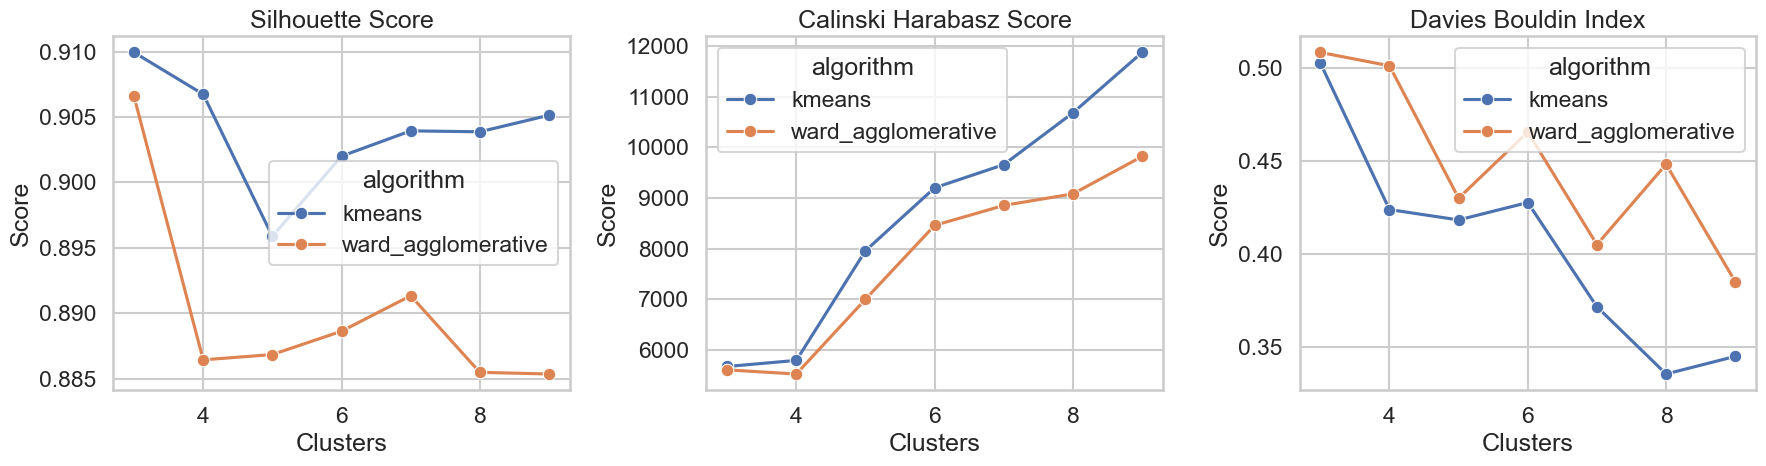

Selected county profile model: kmeans, k=9, average metric rank=2.33


In [131]:
plot_quality_df = cluster_quality_df.melt(
    id_vars=['algorithm', 'k'],
    value_vars=['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_index'],
    var_name='metric',
    value_name='value',
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['silhouette_score', 'calinski_harabasz_score', 'davies_bouldin_index']):
    metric_df = plot_quality_df.loc[plot_quality_df['metric'] == metric]
    sns.lineplot(data=metric_df, x='k', y='value', hue='algorithm', marker='o', ax=ax)
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_xlabel('Clusters')
    ax.set_ylabel('Score')
plt.tight_layout()
plt.show()

print(
    f"Selected county profile model: {best_algorithm}, k={best_k}, "
    f"average metric rank={best_cluster_row['combined_metric_rank']:.2f}"
)

#### Fit the Final Model

In [132]:
cluster_input['cluster'] = best_cluster_model.labels_ if hasattr(best_cluster_model, 'labels_') else best_cluster_model.predict(X)

cluster_sizes = (
    cluster_input.groupby('cluster')
    .agg(counties=('fips', 'size'))
    .sort_index()
)
cluster_sizes

,counties
cluster,
0,2733
1,20
2,73
3,6
4,191
5,2
6,47
7,85
8,1


Use PCA to reduce county features into 2 dimensions for visualizing clusters.

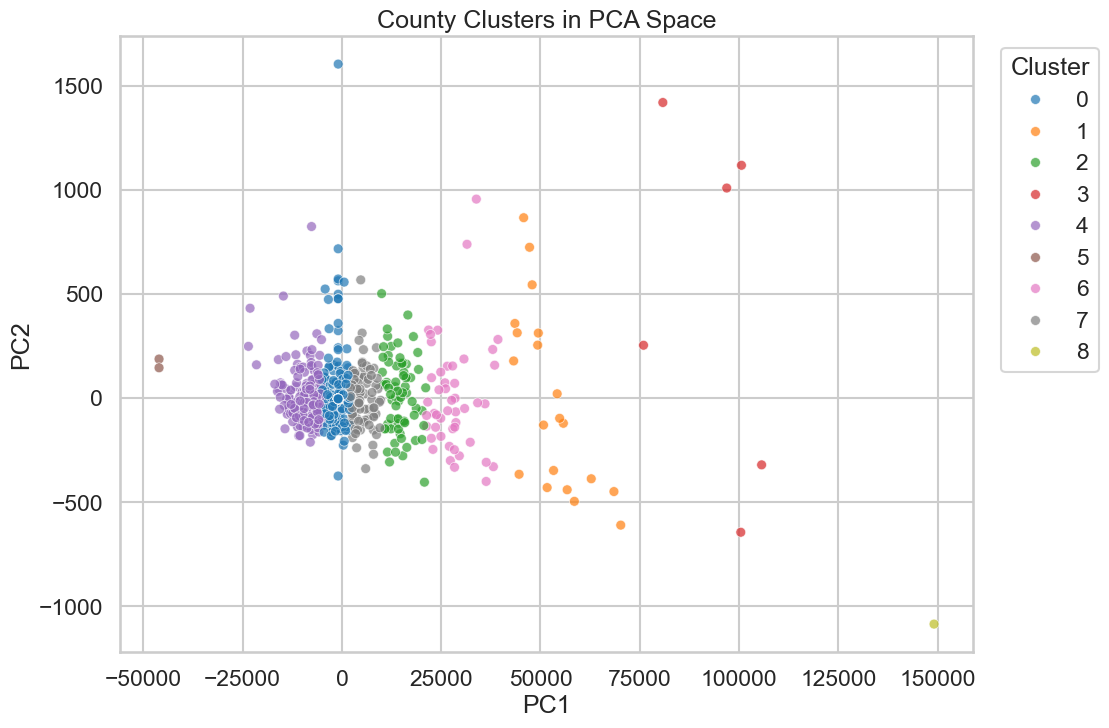

In [133]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
plot_df = cluster_input[['county_name', 'cluster']].copy()
plot_df['pc1'] = coords[:, 0]
plot_df['pc2'] = coords[:, 1]

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(
    data=plot_df.sample(min(5_000, len(plot_df)), random_state=42),
    x='pc1',
    y='pc2',
    hue='cluster',
    palette='tab10',
    alpha=0.7,
    s=50,
    ax=ax,
)
ax.set_title('County Clusters in PCA Space')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

#### Cluster Profiles

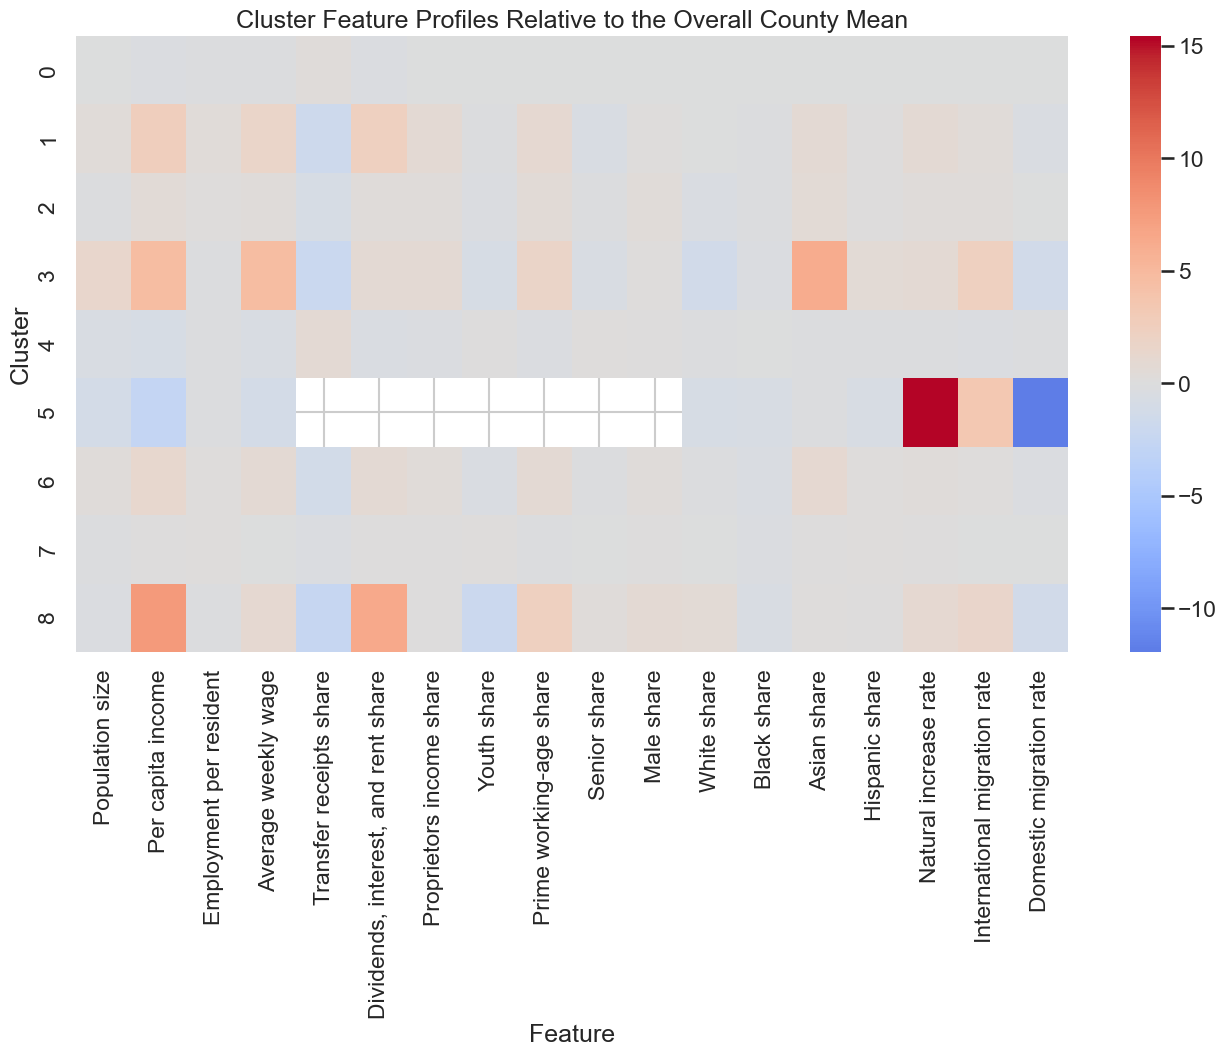

,Population size,Per capita income,Employment per resident,Average weekly wage,Transfer receipts share,"Dividends, interest, and rent share",Proprietors income share,Youth share,Prime working-age share,Senior share,Male share,White share,Black share,Asian share,Hispanic share,Natural increase rate,International migration rate,Domestic migration rate
cluster,,,,,,,,,,,,,,,,,,
0,0.0300,-0.3300,-0.0900,-0.1400,0.2900,-0.3000,-0.0500,0.0100,-0.0200,-0.0000,-0.0300,0.0200,0.0300,-0.0400,-0.0000,-0.0200,-0.0000,0.0300
1,0.3600,2.5600,0.3900,1.5600,-1.7000,2.3000,0.7500,-0.1600,1.0400,-0.5100,0.2300,0.0100,-0.2600,0.8600,0.0600,0.6900,0.4300,-0.3900
2,-0.0800,0.5300,0.1900,0.3500,-0.7900,0.3600,0.2800,-0.3400,0.5000,-0.0700,0.4200,-0.4000,-0.2500,0.5900,0.0900,0.2600,0.2600,-0.0100
3,1.4300,4.7200,-0.2100,4.7200,-2.1000,0.8400,0.8500,-0.7200,1.7900,-0.5000,0.1600,-1.3700,-0.3300,6.1900,0.6200,0.7600,2.3800,-1.4200
4,-0.5200,-0.7200,-0.1600,-0.5100,0.7900,-0.4600,-0.3200,0.0900,-0.3100,0.1900,0.1100,-0.1100,0.0300,-0.2600,-0.1600,-0.2000,-0.2900,-0.1500
5,-1.1900,-2.6700,-0.2400,-1.1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.8100,-0.6500,-0.2100,-0.6100,15.4300,3.3600,-11.9400
6,0.2700,1.2600,0.2100,0.7700,-1.3000,0.7500,0.3600,-0.4900,0.8100,-0.1100,0.3500,-0.1100,-0.4400,1.0800,0.2100,0.2700,0.2300,-0.3700
7,-0.0800,0.0400,0.1600,-0.0300,-0.2900,0.1300,0.1200,0.1800,-0.0900,-0.0100,0.0800,0.0300,-0.3800,0.0700,0.1900,0.0500,0.0000,-0.0200
8,-0.3400,7.6700,-0.2000,1.0400,-2.4400,6.3700,0.1200,-1.9900,2.3700,0.3200,0.7900,0.6300,-0.5800,0.1500,0.0600,1.1000,1.4700,-1.4400


In [134]:
cluster_feature_means = cluster_input.groupby('cluster')[FEATURE_COLUMNS].mean()
overall_feature_means = cluster_input[FEATURE_COLUMNS].mean()
overall_feature_std = cluster_input[FEATURE_COLUMNS].std().replace(0, np.nan)
cluster_zscores = (cluster_feature_means - overall_feature_means) / overall_feature_std

heatmap_df = cluster_zscores.rename(columns=FEATURE_LABELS)
plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_df, cmap='coolwarm', center=0)
plt.title('Cluster Feature Profiles Relative to the Overall County Mean')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.show()

heatmap_df.round(2)

#### Written Interpretation of Each Cluster

In [135]:
cluster_interpretations = []
for cluster_id in cluster_zscores.index:
    county_count = int(cluster_sizes.loc[cluster_id, 'counties'])
    interpretation = summarize_cluster(cluster_zscores.loc[cluster_id], county_count)
    examples = ', '.join(
        cluster_input.loc[cluster_input['cluster'] == cluster_id, 'county_name']
        .drop_duplicates()
        .head(8)
        .tolist()
    )
    cluster_interpretations.append({
        'county_profile': cluster_id,
        'county_profile_desc': interpretation,
        'example_counties': examples,
    })

cluster_interpretations_df = pd.DataFrame(cluster_interpretations)
cluster_interpretations_df

,county_profile,county_profile_desc,example_counties
0,0,"This cluster contains 2,733 counties. It is di...","Autauga County, AL, Butler County, AL, Choctaw..."
1,1,This cluster contains 20 counties. It is disti...,"Denali Borough, AK, Benton County, AR, Alameda..."
2,2,This cluster contains 73 counties. It is disti...,"Jefferson County, AL, Madison County, AL, Shel..."
3,3,This cluster contains 6 counties. It is distin...,"Bristol Bay Borough, AK, Marin County, CA, San..."
4,4,This cluster contains 191 counties. It is dist...,"Barbour County, AL, Bibb County, AL, Blount Co..."
5,5,This cluster contains 2 counties. It is distin...,"Skagway-Hoonah-Angoon Borough, AK, Wrangell-Pe..."
6,6,This cluster contains 47 counties. It is disti...,"Anchorage Borough, AK, Haines Borough, AK, Jun..."
7,7,This cluster contains 85 counties. It is disti...,"Baldwin County, AL, Limestone County, AL, Mata..."
8,8,This cluster contains 1 counties. It is distin...,"Pitkin County, CO"


In [136]:
for row in cluster_interpretations_df.itertuples(index=False):
    print(f"County profile {row.county_profile}")
    print(row.county_profile_desc)
    print(f"Example counties: {row.example_counties}")
    print('-' * 120)

County profile 0
This cluster contains 2,733 counties. It is distinguished by Transfer receipts share (0.3 SD above average); Domestic migration rate (0.0 SD above average); Population size (0.0 SD above average). It is relatively low on Per capita income (0.3 SD below average); Dividends, interest, and rent share (0.3 SD below average); Average weekly wage (0.1 SD below average).
Example counties: Autauga County, AL, Butler County, AL, Choctaw County, AL, Clarke County, AL, Coffee County, AL, Colbert County, AL, Crenshaw County, AL, Cullman County, AL
------------------------------------------------------------------------------------------------------------------------
County profile 1
This cluster contains 20 counties. It is distinguished by Per capita income (2.6 SD above average); Dividends, interest, and rent share (2.3 SD above average); Average weekly wage (1.6 SD above average). It is relatively low on Transfer receipts share (1.7 SD below average); Senior share (0.5 SD below 

#### Summary of Clusters

The selected County Profiles are generated from the best-ranked clustering model above. 
Each profile interpretation describes the socio-economic characteristics that are most above and below the national county average.

In [137]:
county_profiles_summary_df = cluster_interpretations_df[['county_profile', 'county_profile_desc']].copy()
county_profiles_summary_df['county_profile_algorithm'] = best_algorithm
county_profiles_summary_df['county_profile_k'] = best_k
county_profiles_summary_df['county_profile_silhouette'] = float(best_cluster_row['silhouette_score'])
county_profiles_summary_df['county_profile_calinski_harabasz'] = float(best_cluster_row['calinski_harabasz_score'])
county_profiles_summary_df['county_profile_davies_bouldin'] = float(best_cluster_row['davies_bouldin_index'])
county_profiles_summary_df['county_profile_combined_metric_rank'] = float(best_cluster_row['combined_metric_rank'])

county_profile_df = (
    cluster_input[['fips', 'county_name', 'cluster']]
    .rename(columns={'cluster': 'county_profile'})
    .merge(
        county_profiles_summary_df,
        on='county_profile',
        how='left',
    )
)

county_profiles_output_path = ROOT / 'output' / 'visualizations' / 'county_profiles.csv'
county_profile_assignments_output_path = ROOT / 'output' / 'visualizations' / 'county_profile_assignments.csv'
county_profile_model_output_path = ROOT / 'output' / 'visualizations' / 'county_profile_model.joblib'
county_profiles_output_path.parent.mkdir(parents=True, exist_ok=True)
county_profiles_summary_df.to_csv(county_profiles_output_path, index=False)
county_profile_df.to_csv(county_profile_assignments_output_path, index=False)

dump({
    'preprocess_pipeline': county_profile_preprocess,
    'model': best_cluster_model,
    'algorithm': best_algorithm,
    'k': best_k,
    'feature_columns': FEATURE_COLUMNS,
    'feature_labels': FEATURE_LABELS,
    'selection_metrics': best_cluster_row.to_dict(),
    'cluster_interpretations': cluster_interpretations_df.to_dict(orient='records'),
}, county_profile_model_output_path)

housing_df = (
    housing_df.drop(columns=[
        'county_profile',
        'county_profile_desc',
        'county_profile_algorithm',
        'county_profile_k',
        'county_profile_silhouette',
        'county_profile_calinski_harabasz',
        'county_profile_davies_bouldin',
        'county_profile_combined_metric_rank',
    ], errors='ignore')
    .merge(
        county_profile_df.drop(columns='county_name'),
        on='fips',
        how='left',
    )
)

print(county_profiles_output_path)
print(county_profile_assignments_output_path)
print(county_profile_model_output_path)
county_profile_df.head()

globals().pop("_housing_lookup_cache", None)
globals().pop("_prepared_incident_df_cache", None)

c:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\county_profiles.csv
c:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\county_profile_assignments.csv
c:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\county_profile_model.joblib


{'__all__':         fips        county_name state  disasterNumber declarationDate  \
 0      41067  Washington County    OR            5529      2024-08-09   
 1      41031   Jefferson County    OR            5528      2024-08-06   
 2      41017   Deschutes County    OR            5527      2024-08-02   
 3      06000                NaN    CA            4312      2017-05-02   
 9      41001       Baker County    OR            5516      2024-07-22   
 ...      ...                ...   ...             ...             ...   
 65457  06111     Ventura County    CA            3591      2023-01-09   
 65458  06113        Yolo County    CA            3591      2023-01-09   
 65459  06115        Yuba County    CA            3591      2023-01-09   
 65460  36029        Erie County    NY            3590      2022-12-26   
 65461  36037     Genesee County    NY            3590      2022-12-26   
 
        incidentType                               declarationTitle  \
 0              Fire        

## Cluster County PPSF YOY Responses by Incident Type

For each natural disaster incident type, this subsection builds complete county response windows from 12 months before incident start through 24 months after incident end. It keeps only county-incident observations with `MEDIAN_PPSF_YOY` values for every required month, reduces each response to summary features, recency-weights multiple incidents for the same county, and compares fixed cluster counts from 2 through 5. Ward-linkage agglomerative clustering is the main method; KMeans is retained as a benchmark.


### Hyperparameter Tuning and Evaluation

In [138]:
'''
Hyperparamter tuning:
- Number of clusters, k, from 2 to 5
- Clustering algorithm: KMeans, Agglomerative Clustering

Evaluation metric: Silhouette score
'''

from sklearn.cluster import AgglomerativeClustering

PPSF_RESPONSE_MONTHS_BEFORE = 12
PPSF_RESPONSE_MONTHS_AFTER = 24
PPSF_PRE_OFFSETS = list(range(-PPSF_RESPONSE_MONTHS_BEFORE, 0))
PPSF_POST_1_12_OFFSETS = list(range(1, 13))
PPSF_POST_13_24_OFFSETS = list(range(13, PPSF_RESPONSE_MONTHS_AFTER + 1))
PPSF_RESPONSE_OFFSETS = PPSF_PRE_OFFSETS + PPSF_POST_1_12_OFFSETS + PPSF_POST_13_24_OFFSETS
PPSF_RESPONSE_K_VALUES = [2, 3, 4, 5]
# Clustering will be performed on the following features derived from the month-by-month response vectors for each incident:
PPSF_RESPONSE_FEATURES = [
    "pre_period_mean",
    "post_months_1_12_mean",
    "post_months_13_24_mean",
    "post_minus_pre_change",
    "volatility",
    "max_drawdown",
    "recovery_slope",
]
PPSF_RESPONSE_EXCLUDED_INCIDENT_TYPES = {
    "Biological",
    "Chemical",
    "Other",
    "Human Cause",
    "Terrorist",
    "Fishing Losses",
    "Dam/Levee Break",
    "Toxic Substances",
}


def _build_complete_median_ppsf_yoy_incident_response_rows(incident_type):
    incident_df = natural_disasters_df.loc[
        (natural_disasters_df["incidentType"] == incident_type)
        & (~natural_disasters_df["incidentType"].isin(PPSF_RESPONSE_EXCLUDED_INCIDENT_TYPES))
    ].copy()
    if incident_df.empty:
        return pd.DataFrame()

    incident_duration = incident_df["incidentEndDate"] - incident_df["incidentBeginDate"]
    median_duration = incident_duration[incident_duration.notna()].median()
    if pd.isna(median_duration):
        median_duration = pd.Timedelta(days=0)

    incident_df["incidentEndDate"] = incident_df["incidentEndDate"].fillna(
        incident_df["incidentBeginDate"] + median_duration
    )
    incident_df = incident_df.dropna(subset=["incidentBeginDate", "incidentEndDate", "fips"]).copy()
    incident_df["incident_begin_month"] = incident_df["incidentBeginDate"].dt.to_period("M")
    incident_df["incident_end_month"] = incident_df["incidentEndDate"].dt.to_period("M")
    incident_df["event_id"] = np.arange(len(incident_df))

    housing_with_keys = housing_df.copy()
    housing_with_keys["fips_normalized"] = housing_with_keys["fips"].astype(str).str.zfill(5)
    housing_with_keys["state_prefix"] = housing_with_keys["fips_normalized"].str[:2]
    housing_with_keys["is_county"] = ~housing_with_keys["fips_normalized"].str.endswith("000")
    county_housing = housing_with_keys.loc[housing_with_keys["is_county"]].copy()

    county_by_fips = {
        fips: group.copy()
        for fips, group in county_housing.groupby("fips_normalized", sort=False)
    }
    counties_by_state = {
        state_prefix: group.copy()
        for state_prefix, group in county_housing.groupby("state_prefix", sort=False)
    }

    response_rows = []
    for event in incident_df.itertuples(index=False):
        event_fips = str(event.fips).zfill(5)
        if event_fips.endswith("000"):
            affected_housing = counties_by_state.get(event_fips[:2])
        else:
            affected_housing = county_by_fips.get(event_fips)
        if affected_housing is None or affected_housing.empty:
            continue

        offset_lookup = {
            event.incident_begin_month + offset: offset
            for offset in PPSF_PRE_OFFSETS
        }
        offset_lookup.update({
            event.incident_end_month + offset: offset
            for offset in PPSF_POST_1_12_OFFSETS + PPSF_POST_13_24_OFFSETS
        })

        event_rows = affected_housing.loc[affected_housing["MONTH"].isin(offset_lookup)].copy()
        if event_rows.empty:
            continue

        event_rows["month_offset_from_incident"] = event_rows["MONTH"].map(offset_lookup).astype("Int64")
        event_rows["incident_type"] = incident_type
        event_rows["incident_event_id"] = event.event_id
        event_rows["incident_disaster_number"] = event.disasterNumber
        event_rows["incident_begin_date"] = event.incidentBeginDate
        response_rows.append(event_rows)

    if not response_rows:
        return pd.DataFrame()

    return pd.concat(response_rows, ignore_index=True)


def _fit_recovery_slope(values_by_offset):
    post_offsets = PPSF_POST_1_12_OFFSETS + PPSF_POST_13_24_OFFSETS
    post_x = np.array(post_offsets, dtype=float)
    post_values = values_by_offset.loc[post_offsets].to_numpy(dtype=float)
    return np.polyfit(post_x, post_values, 1)[0]


def _summarize_complete_incident_vectors(response_rows):
    event_vectors = (
        response_rows
        .pivot_table(
            index=["fips", "county_name", "incident_event_id", "incident_begin_date"],
            columns="month_offset_from_incident",
            values="MEDIAN_PPSF_YOY",
            aggfunc="mean",
        )
        .reindex(columns=PPSF_RESPONSE_OFFSETS)
        .dropna(subset=PPSF_RESPONSE_OFFSETS)
        .reset_index()
    )
    if event_vectors.empty:
        return event_vectors

    feature_rows = []
    for _, row in event_vectors.iterrows():
        values_by_offset = row[PPSF_RESPONSE_OFFSETS].astype(float)
        pre_values = values_by_offset.loc[PPSF_PRE_OFFSETS]
        post_1_12_values = values_by_offset.loc[PPSF_POST_1_12_OFFSETS]
        post_13_24_values = values_by_offset.loc[PPSF_POST_13_24_OFFSETS]
        post_values = values_by_offset.loc[PPSF_POST_1_12_OFFSETS + PPSF_POST_13_24_OFFSETS]

        pre_mean = pre_values.mean()
        post_1_12_mean = post_1_12_values.mean()
        post_13_24_mean = post_13_24_values.mean()
        post_mean = post_values.mean()

        feature_rows.append({
            "fips": row["fips"],
            "county_name": row["county_name"],
            "incident_event_id": row["incident_event_id"],
            "incident_begin_date": row["incident_begin_date"],
            "pre_period_mean": pre_mean,
            "post_months_1_12_mean": post_1_12_mean,
            "post_months_13_24_mean": post_13_24_mean,
            "post_minus_pre_change": post_mean - pre_mean,
            "volatility": values_by_offset.std(ddof=0),
            "max_drawdown": post_values.min() - pre_mean,
            "recovery_slope": _fit_recovery_slope(values_by_offset),
        })

    return pd.DataFrame(feature_rows)


def _weighted_average_incident_features(event_features, feature_columns):
    event_features = event_features.copy()
    event_features["incident_recency_rank"] = event_features["incident_begin_date"].rank(
        method="dense",
        ascending=True,
    ).astype(float)

    averaged_rows = []
    for (fips, county_name), county_events in event_features.groupby(["fips", "county_name"], dropna=False):
        weights = county_events["incident_recency_rank"].to_numpy(dtype=float)
        averaged = {"fips": fips, "county_name": county_name}
        for column in feature_columns:
            values = pd.to_numeric(county_events[column], errors="coerce").to_numpy(dtype=float)
            valid = ~np.isnan(values)
            averaged[column] = np.average(values[valid], weights=weights[valid]) if valid.any() else np.nan
        averaged["incident_count"] = county_events["incident_event_id"].nunique()
        averaged["latest_incident_begin_date"] = county_events["incident_begin_date"].max()
        averaged_rows.append(averaged)

    return pd.DataFrame(averaged_rows)


def build_median_ppsf_response_clusters(incident_type, k_values=PPSF_RESPONSE_K_VALUES):
    response_rows = _build_complete_median_ppsf_yoy_incident_response_rows(incident_type)
    if response_rows.empty:
        return None, None, {"incident_type": incident_type, "status": "no housing rows in complete incident window"}

    event_features = _summarize_complete_incident_vectors(response_rows)
    if event_features.empty:
        return None, None, {"incident_type": incident_type, "status": "no complete county-incident PPSF YOY windows"}

    county_features = _weighted_average_incident_features(event_features, PPSF_RESPONSE_FEATURES)
    county_features = county_features.replace([np.inf, -np.inf], np.nan).dropna(subset=PPSF_RESPONSE_FEATURES).copy()

    if len(county_features) < min(PPSF_RESPONSE_K_VALUES) + 1:
        return county_features, None, {
            "incident_type": incident_type,
            "status": "not enough counties with complete PPSF YOY response features",
            "counties_clustered": len(county_features),
            "complete_county_incident_vectors": len(event_features),
        }

    X_response = StandardScaler().fit_transform(county_features[PPSF_RESPONSE_FEATURES])
    comparison_rows = []

    def add_clustering_result(algorithm, k, labels, cluster_col):
        county_features[cluster_col] = labels
        comparison_rows.append({
            "incident_type": incident_type,
            "algorithm": algorithm,
            "k": k,
            "status": "clustered",
            "counties_clustered": len(county_features),
            "complete_county_incident_vectors": len(event_features),
            "silhouette_score": silhouette_score(
                X_response,
                labels,
                sample_size=min(10_000, len(county_features)),
                random_state=42,
            ),
            "cluster_sizes": county_features[cluster_col].value_counts().sort_index().to_dict(),
        })

    for k in k_values:
        if k >= len(county_features):
            for algorithm in ["ward_agglomerative", "kmeans_benchmark"]:
                comparison_rows.append({
                    "incident_type": incident_type,
                    "algorithm": algorithm,
                    "k": k,
                    "status": "skipped",
                    "counties_clustered": len(county_features),
                    "complete_county_incident_vectors": len(event_features),
                    "silhouette_score": np.nan,
                    "cluster_sizes": {},
                })
            continue

        ward_model = AgglomerativeClustering(n_clusters=k, linkage="ward")
        ward_labels = ward_model.fit_predict(X_response)
        ward_cluster_col = f"median_ppsf_response_cluster_k{k}"
        add_clustering_result("ward_agglomerative", k, ward_labels, ward_cluster_col)

        kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=20)
        kmeans_labels = kmeans_model.fit_predict(X_response)
        kmeans_cluster_col = f"median_ppsf_response_kmeans_cluster_k{k}"
        add_clustering_result("kmeans_benchmark", k, kmeans_labels, kmeans_cluster_col)

    comparison_df = pd.DataFrame(comparison_rows)
    ward_results = comparison_df.loc[comparison_df["algorithm"] == "ward_agglomerative"].copy()
    kmeans_results = comparison_df.loc[comparison_df["algorithm"] == "kmeans_benchmark"].copy()
    best_ward_row = ward_results.loc[ward_results["silhouette_score"].idxmax()] if ward_results["silhouette_score"].notna().any() else None
    best_kmeans_row = kmeans_results.loc[kmeans_results["silhouette_score"].idxmax()] if kmeans_results["silhouette_score"].notna().any() else None
    summary = {
        "incident_type": incident_type,
        "status": "clustered" if best_ward_row is not None else "no valid k",
        "primary_algorithm": "ward_agglomerative",
        "benchmark_algorithm": "kmeans_benchmark",
        "counties_clustered": len(county_features),
        "complete_county_incident_vectors": len(event_features),
        "best_ward_k_by_silhouette": int(best_ward_row["k"]) if best_ward_row is not None else pd.NA,
        "best_ward_silhouette_score": float(best_ward_row["silhouette_score"]) if best_ward_row is not None else np.nan,
        "best_kmeans_k_by_silhouette": int(best_kmeans_row["k"]) if best_kmeans_row is not None else pd.NA,
        "best_kmeans_silhouette_score": float(best_kmeans_row["silhouette_score"]) if best_kmeans_row is not None else np.nan,
    }
    return county_features, comparison_df, summary


ppsf_response_cluster_results = {}
ppsf_response_cluster_comparisons = []
ppsf_response_cluster_summaries = []

ppsf_response_incident_types = sorted(
    natural_disasters_df.loc[
        ~natural_disasters_df["incidentType"].isin(PPSF_RESPONSE_EXCLUDED_INCIDENT_TYPES),
        "incidentType",
    ].dropna().unique()
)

for incident_type in ppsf_response_incident_types:
    county_features, comparison_df, summary = build_median_ppsf_response_clusters(incident_type)
    ppsf_response_cluster_results[incident_type] = county_features
    if comparison_df is not None:
        ppsf_response_cluster_comparisons.append(comparison_df)
    ppsf_response_cluster_summaries.append(summary)

ppsf_response_cluster_comparison_df = (
    pd.concat(ppsf_response_cluster_comparisons, ignore_index=True)
    if ppsf_response_cluster_comparisons else pd.DataFrame()
)
ppsf_response_cluster_summary_df = pd.DataFrame(ppsf_response_cluster_summaries)
ppsf_response_cluster_comparison_df


,incident_type,algorithm,k,status,counties_clustered,complete_county_incident_vectors,silhouette_score,cluster_sizes
0,Coastal Storm,ward_agglomerative,2,clustered,45,118,0.8237,"{0: 44, 1: 1}"
1,Coastal Storm,kmeans_benchmark,2,clustered,45,118,0.8237,"{0: 44, 1: 1}"
2,Coastal Storm,ward_agglomerative,3,clustered,45,118,0.5378,"{0: 9, 1: 1, 2: 35}"
3,Coastal Storm,kmeans_benchmark,3,clustered,45,118,0.5476,"{0: 36, 1: 8, 2: 1}"
4,Coastal Storm,ward_agglomerative,4,clustered,45,118,0.4680,"{0: 4, 1: 5, 2: 35, 3: 1}"
...,...,...,...,...,...,...,...,...
91,Winter Storm,kmeans_benchmark,3,clustered,123,140,0.3824,"{0: 85, 1: 2, 2: 36}"
92,Winter Storm,ward_agglomerative,4,clustered,123,140,0.3791,"{0: 2, 1: 13, 2: 89, 3: 19}"
93,Winter Storm,kmeans_benchmark,4,clustered,123,140,0.3726,"{0: 10, 1: 2, 2: 38, 3: 73}"
94,Winter Storm,ward_agglomerative,5,clustered,123,140,0.3761,"{0: 13, 1: 19, 2: 89, 3: 1, 4: 1}"


### Select Clustering Model

For each incident type, select the hyperparameters that yield the highest silhouette score, and use those to fit the final clustering model and assign cluster labels to each incident event.

In [139]:
def summarize_ppsf_response_cluster(cluster_means):
    pre = cluster_means['pre_period_mean']
    early = cluster_means['post_months_1_12_mean']
    late = cluster_means['post_months_13_24_mean']
    change = cluster_means['post_minus_pre_change']
    drawdown = cluster_means['max_drawdown']
    slope = cluster_means['recovery_slope']
    volatility = cluster_means['volatility']

    if change >= 0.035 and late >= early:
        name = 'Post-event acceleration'
        interpretation = 'Median PPSF YOY strengthens after the event and remains elevated through months 13-24.'
    elif change >= 0.015:
        name = 'Moderate price lift'
        interpretation = 'Median PPSF YOY rises modestly after the event, indicating a firmer price response than before the event.'
    elif change <= -0.035 and late <= early:
        name = 'Persistent price softening'
        interpretation = 'Median PPSF YOY weakens after the event and stays below the pre-event pace through months 13-24.'
    elif change <= -0.015:
        name = 'Moderate price cooling'
        interpretation = 'Median PPSF YOY cools after the event, but the shift is less severe or less persistent.'
    elif slope > 0.001:
        name = 'Recovery pattern'
        interpretation = 'The post-event trajectory improves over time, suggesting counties regain pricing momentum after an initial shock.'
    elif drawdown < -0.08:
        name = 'Shock then stabilization'
        interpretation = 'Counties see a notable post-event downside move, followed by a more stable later response.'
    elif volatility > 0.08:
        name = 'Volatile response'
        interpretation = 'The housing response is uneven across the 24-month post-event window, with larger month-to-month swings.'
    else:
        name = 'Stable response'
        interpretation = 'Median PPSF YOY remains close to the pre-event pattern, indicating limited county-level price disruption.'

    interpretation += (
        f" Average pre-event PPSF YOY is {pre:.1%}; months 1-12 average {early:.1%}; "
        f"months 13-24 average {late:.1%}; post-minus-pre change is {change:.1%}."
    )
    return name, interpretation


ppsf_response_best_cluster_rows = (
    ppsf_response_cluster_comparison_df
    .dropna(subset=['silhouette_score'])
    .sort_values(['incident_type', 'silhouette_score'], ascending=[True, False])
    .groupby('incident_type', as_index=False, group_keys=False)
    .head(1)
    .copy()
)

ppsf_response_cluster_annotation_frames = []
ppsf_response_cluster_interpretation_rows = []

for best_row in ppsf_response_best_cluster_rows.itertuples(index=False):
    incident_type = best_row.incident_type
    county_features = ppsf_response_cluster_results.get(incident_type)
    if county_features is None or county_features.empty:
        continue

    if best_row.algorithm == 'ward_agglomerative':
        cluster_col = f'median_ppsf_response_cluster_k{int(best_row.k)}'
    else:
        cluster_col = f'median_ppsf_response_kmeans_cluster_k{int(best_row.k)}'

    if cluster_col not in county_features.columns:
        continue

    annotated = county_features[['fips', 'county_name', 'incident_count', cluster_col] + PPSF_RESPONSE_FEATURES].copy()
    annotated = annotated.rename(columns={
        cluster_col: 'median_ppsf_response_cluster',
        'incident_count': 'median_ppsf_response_incident_count',
    })
    annotated['incident_type'] = incident_type
    annotated['median_ppsf_response_cluster_algorithm'] = best_row.algorithm
    annotated['median_ppsf_response_cluster_k'] = int(best_row.k)
    annotated['median_ppsf_response_cluster_silhouette'] = float(best_row.silhouette_score)

    cluster_means = annotated.groupby('median_ppsf_response_cluster')[PPSF_RESPONSE_FEATURES].mean()
    cluster_sizes = annotated['median_ppsf_response_cluster'].value_counts().sort_index()
    interpretation_map = {}
    label_map = {}
    for cluster_id, means in cluster_means.iterrows():
        label, interpretation = summarize_ppsf_response_cluster(means)
        label_map[cluster_id] = label
        interpretation_map[cluster_id] = interpretation
        ppsf_response_cluster_interpretation_rows.append({
            'incident_type': incident_type,
            'cluster': int(cluster_id),
            'cluster_name': label,
            'interpretation': interpretation,
            'counties': int(cluster_sizes.loc[cluster_id]),
            'algorithm': best_row.algorithm,
            'k': int(best_row.k),
            'silhouette_score': float(best_row.silhouette_score),
        })

    annotated['median_ppsf_response_cluster_name'] = annotated['median_ppsf_response_cluster'].map(label_map)
    annotated['median_ppsf_response_cluster_interpretation'] = annotated['median_ppsf_response_cluster'].map(interpretation_map)
    ppsf_response_cluster_annotation_frames.append(annotated)

ppsf_response_cluster_annotations_df = (
    pd.concat(ppsf_response_cluster_annotation_frames, ignore_index=True)
    if ppsf_response_cluster_annotation_frames else pd.DataFrame()
)
ppsf_response_cluster_interpretations_df = pd.DataFrame(ppsf_response_cluster_interpretation_rows)

ppsf_response_best_cluster_rows



,incident_type,algorithm,k,status,counties_clustered,complete_county_incident_vectors,silhouette_score,cluster_sizes
0,Coastal Storm,ward_agglomerative,2,clustered,45,118,0.8237,"{0: 44, 1: 1}"
8,Earthquake,ward_agglomerative,2,clustered,62,69,0.8566,"{0: 61, 1: 1}"
19,Fire,kmeans_benchmark,3,clustered,313,1448,0.4568,"{0: 16, 1: 227, 2: 70}"
25,Flood,kmeans_benchmark,2,clustered,1070,3793,0.4952,"{0: 172, 1: 898}"
32,Hurricane,ward_agglomerative,2,clustered,841,5608,0.5386,"{0: 100, 1: 741}"
40,Mud/Landslide,ward_agglomerative,2,clustered,111,183,0.5486,"{0: 16, 1: 95}"
48,Severe Ice Storm,ward_agglomerative,2,clustered,485,813,0.5716,"{0: 459, 1: 26}"
57,Severe Storm,kmeans_benchmark,2,clustered,1281,3244,0.4740,"{0: 1044, 1: 237}"
64,Snowstorm,ward_agglomerative,2,clustered,155,168,0.7495,"{0: 4, 1: 151}"
74,Tornado,ward_agglomerative,3,clustered,125,160,0.3712,"{0: 102, 1: 16, 2: 7}"


## Build Incident-Housing Datasets

Create subset DataFrames of county housing data that fall within the incident window for each incident type, excluding `Biological`, `Chemical`, `Other`, `Human Cause`, `Terrorist`, `Fishing Losses`, `Dam/Levee Break`, and `Toxic Substances`.
State-level incidents are mapped to county housing rows through the county lookup keyed by county FIPS and state prefix.

Transformation steps:
- Impute missing `incidentEndDate` values with the estimated end date based on the median duration of that incident type
- Get the monthly periods for natural disasters to determine the incident window to filter on housing data
- Measure the monthly change in YOY values


In [140]:
'''
Get subsets of housing data that falls within incident window using pandas dataframe
get_housing_data_in_window(): Returns county-level housing data for the period of 12-months before incident start to 12-months after incident end
get_housing_data_in_window2(): Returns county-level housing data for the period of 12-months before incident start to 24-months after incident end
'''

ECONOMIC_BIN_COUNT = 5

def _add_quantile_bins(df, source_col, target_col, bins = ECONOMIC_BIN_COUNT):
    numeric_values = pd.to_numeric(df[source_col], errors = "coerce")
    result = pd.Series(pd.NA, index = df.index, dtype = "Int64")
    valid_mask = numeric_values.notna()
    if valid_mask.sum() == 0:
        df[target_col] = result
        return df

    try:
        binned = pd.qcut(numeric_values[valid_mask], q = bins, labels = False, duplicates = "drop")
    except ValueError:
        df[target_col] = result
        return df

    result.loc[valid_mask] = pd.Series(binned, index = numeric_values[valid_mask].index).astype("Int64") + 1
    df[target_col] = result
    return df

def _get_housing_lookup_cache():
    cache = globals().get("_housing_lookup_cache")
    if cache is not None:
        return cache

    housing_with_keys = housing_df.copy()
    housing_with_keys["fips_normalized"] = housing_with_keys["fips"].astype(str).str.zfill(5)
    housing_with_keys["state_prefix"] = housing_with_keys["fips_normalized"].str[:2]
    housing_with_keys["is_county"] = ~housing_with_keys["fips_normalized"].str.endswith("000")
    housing_with_keys = _add_quantile_bins(housing_with_keys, "per_capita_income", "per_capita_income_bin")
    housing_with_keys = _add_quantile_bins(housing_with_keys, "employment", "employment_bin")
    housing_with_keys = _add_quantile_bins(housing_with_keys, "average_wage_per_job", "average_wage_per_job_bin")

    county_rows = housing_with_keys[housing_with_keys["is_county"]].copy()
    county_by_fips = {
        fips: {"data": group.copy(), "months": set(group["MONTH"])}
        for fips, group in county_rows.groupby("fips_normalized", sort = False)
    }
    counties_by_state = {
        state_prefix: {"data": group.copy(), "months": set(group["MONTH"])}
        for state_prefix, group in county_rows.groupby("state_prefix", sort = False)
    }

    cache = {
        "county_by_fips": county_by_fips,
        "counties_by_state": counties_by_state,
        "empty": housing_with_keys.iloc[0:0].copy(),
    }
    globals()["_housing_lookup_cache"] = cache
    return cache

EXCLUDED_INCIDENT_TYPES = {
    "Biological",
    "Chemical",
    "Other",
    "Human Cause",
    "Terrorist",
    "Fishing Losses",
    "Dam/Levee Break",
    "Toxic Substances",
}

def _prepare_incident_df(incident_type = None):
    cache = globals().setdefault("_prepared_incident_df_cache", {})
    cache_key = incident_type or "__all__"
    if cache_key in cache:
        return cache[cache_key]

    if incident_type in EXCLUDED_INCIDENT_TYPES:
        raise ValueError("incident_type is not valid.")

    if incident_type is not None and (natural_disasters_df["incidentType"] == incident_type).any() is False:
        raise ValueError("incident_type is not valid.")

    cutoff_date = pd.Timestamp(year = pd.Timestamp.now().year - 10, month = 1, day = 1)
    incident_df = natural_disasters_df.loc[
        natural_disasters_df["incidentBeginDate"] >= cutoff_date
    ].copy()
    incident_df = incident_df.loc[~incident_df["incidentType"].isin(EXCLUDED_INCIDENT_TYPES)].copy()
    if incident_type is not None:
        incident_df = incident_df.loc[incident_df["incidentType"] == incident_type].copy()

    incident_duration = incident_df["incidentEndDate"] - incident_df["incidentBeginDate"]
    incident_median_duration = incident_duration[incident_duration.notna()].median()
    incident_df["incidentEndDate"] = incident_df["incidentEndDate"].fillna(
        incident_df["incidentBeginDate"] + incident_median_duration
    )
    incident_df["incident_begin_month"] = incident_df["incidentBeginDate"].dt.to_period("M")
    incident_df["incident_end_month"] = incident_df["incidentEndDate"].dt.to_period("M")

    cache[cache_key] = incident_df
    return incident_df

def _build_incident_housing_subset(incident_df, months_before, months_after, after_anchor = "end", complete_after_anchor = None):
    housing_lookup = _get_housing_lookup_cache()
    county_by_fips = housing_lookup["county_by_fips"]
    counties_by_state = housing_lookup["counties_by_state"]
    empty_result = housing_lookup["empty"].copy()

    results = []

    for incident_num, event in enumerate(incident_df.itertuples(index = False), start = 1):
        fips = str(event.fips).zfill(5)
        event_start = event.incident_begin_month
        event_end = event.incident_end_month

        if fips.endswith("000"):
            lookup_entry = counties_by_state.get(fips[:2])
        else:
            lookup_entry = county_by_fips.get(fips)
        if lookup_entry is None:
            continue

        available_months = lookup_entry["months"]
        if complete_after_anchor is not None:
            completion_anchor = event_end if complete_after_anchor == "end" else event_start
            required_after_months = {completion_anchor + offset for offset in range(1, months_after + 1)}
            if not required_after_months.issubset(available_months):
                continue

        after_reference = event_end if after_anchor == "end" else event_start
        offset_lookup = {
            event_start + offset: offset
            for offset in range(-months_before, 0)
        }
        offset_lookup[event_end] = 0
        offset_lookup.update({
            after_reference + offset: offset
            for offset in range(1, months_after + 1)
        })

        window_periods = set(offset_lookup)
        county_prices = lookup_entry["data"].loc[
            lookup_entry["data"]["MONTH"].isin(window_periods)
        ].copy()
        if county_prices.empty:
            continue

        county_prices["month_offset_from_incident"] = county_prices["MONTH"].map(offset_lookup)
        county_prices = county_prices[county_prices["month_offset_from_incident"].notna()].copy()
        if county_prices.empty:
            continue

        county_prices["month_offset_from_incident"] = county_prices["month_offset_from_incident"].astype(int)
        county_prices["incident_num"] = incident_num
        county_prices["incident_type"] = event.incidentType
        results.append(county_prices)

    if not results:
        incident_housing_df = empty_result
        incident_housing_df["month_offset_from_incident"] = pd.Series(dtype = "Int64")
        incident_housing_df["incident_num"] = pd.Series(dtype = "Int64")
        incident_housing_df["incident_type"] = pd.Series(dtype = "object")
    else:
        incident_housing_df = pd.concat(results, ignore_index = True)

    incident_housing_df = incident_housing_df.drop(columns = ["fips_normalized", "state_prefix", "is_county"], errors = "ignore")
    incident_housing_df = incident_housing_df.merge(nri_county_df, on = "fips", how = "left")
    return incident_housing_df

def get_housing_data_in_window(incident_type = None, months = 12):
    try:
        incident_df = _prepare_incident_df(incident_type = incident_type)
    except ValueError:
        return f'incident_type is not valid.'

    return _build_incident_housing_subset(
        incident_df = incident_df,
        months_before = months,
        months_after = months,
        after_anchor = "end",
    )

def get_housing_data_in_window2(incident_type = None, months_before = 12, months_after = 24):
    if months_before < 1 or months_after < 1:
        raise ValueError("months_before and months_after must both be positive integers.")

    incident_df = _prepare_incident_df(incident_type = incident_type)
    return _build_incident_housing_subset(
        incident_df = incident_df,
        months_before = months_before,
        months_after = months_after,
        after_anchor = "end",
        complete_after_anchor = "end",
    )

## Build and Serve Visualization Web Pages

In [141]:

'''
Save incident subsets beside the web visualization and serve the maps locally
'''

from functools import partial
from http.server import ThreadingHTTPServer, SimpleHTTPRequestHandler
import json
from pathlib import Path
import re
import socket
import threading

YOY_12_TO_24_METRICS = {
    "AVG_SALE_TO_LIST": "AVG_SALE_TO_LIST_YOY_MOM",
    "HOMES_SOLD": "HOMES_SOLD_YOY_MOM",
    "INVENTORY": "INVENTORY_YOY_MOM",
    "MEDIAN_PPSF": "MEDIAN_PPSF_YOY_MOM",
}
YOY_12_TO_24_DROP_COLUMNS = [
    "employment",
    "average_wage_per_job",
    "employment_bin",
    "average_wage_per_job_bin",
    "nri_risk_score",
    "nri_risk_rating",
    "nri_risk_rating_date",
]
YOY_12_TO_24_BIN_LABELS = {
    0: "significant_decrease",
    1: "moderate_to_no_change",
    2: "significant_increase",
}


def _find_open_port(host = "127.0.0.1", start = 8000, end = 8100):
    for port in range(start, end + 1):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
            if sock.connect_ex((host, port)) != 0:
                return port
    raise RuntimeError("Could not find an open port for the local visualization server.")


def _incident_type_slug(incident_type):
    slug = re.sub(r"[^a-z0-9]+", "_", str(incident_type).strip().lower())
    return slug.strip("_") or "unknown"


def _assign_three_way_change_bins(series):
    values = pd.to_numeric(series, errors = "coerce")
    result = pd.Series(pd.NA, index = series.index, dtype = "object")
    valid = values.dropna()
    if valid.empty:
        return result

    if valid.nunique() == 1:
        result.loc[valid.index] = YOY_12_TO_24_BIN_LABELS[1]
        return result

    try:
        codes = pd.qcut(valid, q = 3, labels = [0, 1, 2], duplicates = "drop")
    except ValueError:
        result.loc[valid.index] = YOY_12_TO_24_BIN_LABELS[1]
        return result

    if getattr(codes, "cat", None) is not None and len(codes.cat.categories) < 3:
        result.loc[valid.index] = YOY_12_TO_24_BIN_LABELS[1]
        return result

    result.loc[valid.index] = codes.astype("Int64").map(YOY_12_TO_24_BIN_LABELS)
    return result


def _add_change_in_yoy_12_to_24_columns(df):
    if df.empty:
        for metric in YOY_12_TO_24_METRICS:
            base_col = f"{metric}_change_in_yoy_12_to_24"
            df[base_col] = pd.Series(dtype = "float64")
            df[f"{base_col}_bin"] = pd.Series(dtype = "object")
        return df

    out = df.copy()
    group_cols = ["fips", "incident_num"]

    for metric, yoy_mom_col in YOY_12_TO_24_METRICS.items():
        base_col = f"{metric}_change_in_yoy_12_to_24"
        if yoy_mom_col not in out.columns:
            out[base_col] = pd.NA
            out[f"{base_col}_bin"] = pd.NA
            continue

        grouped = (
            out.groupby(group_cols, dropna = False)
            .apply(
                lambda group: pd.Series({
                    "months_1_12": pd.to_numeric(
                        group.loc[group["month_offset_from_incident"].between(1, 12), yoy_mom_col],
                        errors = "coerce",
                    ).mean(),
                    "months_13_24": pd.to_numeric(
                        group.loc[group["month_offset_from_incident"].between(13, 24), yoy_mom_col],
                        errors = "coerce",
                    ).mean(),
                })
            )
            .reset_index()
        )
        grouped[base_col] = grouped["months_13_24"] - grouped["months_1_12"]
        grouped[f"{base_col}_bin"] = _assign_three_way_change_bins(grouped[base_col])
        grouped = grouped[group_cols + [base_col, f"{base_col}_bin"]]
        out = out.merge(grouped, on = group_cols, how = "left")

    return out


def launch_bivariate_map(incident_type = None, months = 12, host = "127.0.0.1", port = None):
    output_dir = Path("..") / "output" / "visualizations"
    output_dir.mkdir(parents = True, exist_ok = True)

    prepared_incidents = _prepare_incident_df(incident_type = incident_type)
    incident_types = sorted(prepared_incidents["incidentType"].dropna().unique())

    incident_housing_dfs = {}
    incident_housing_24m_dfs = {}
    csv_paths = {}
    manifest_entries = []

    for current_incident_type in incident_types:
        housing_subset = get_housing_data_in_window(incident_type = current_incident_type, months = months)
        if isinstance(housing_subset, str):
            raise ValueError(housing_subset)

        housing_subset_24m = get_housing_data_in_window2(
            incident_type = current_incident_type,
            months_before = 12,
            months_after = 24,
        )
        housing_subset_24m = _add_change_in_yoy_12_to_24_columns(housing_subset_24m)
        housing_subset_24m = housing_subset_24m.drop(columns = YOY_12_TO_24_DROP_COLUMNS, errors = "ignore")

        cluster_annotations = globals().get("ppsf_response_cluster_annotations_df")
        if cluster_annotations is not None and not cluster_annotations.empty:
            cluster_columns = [
                "median_ppsf_response_cluster",
                "median_ppsf_response_cluster_name",
                "median_ppsf_response_cluster_interpretation",
                "median_ppsf_response_cluster_algorithm",
                "median_ppsf_response_cluster_k",
                "median_ppsf_response_cluster_silhouette",
                "median_ppsf_response_incident_count",
            ]
            current_cluster_annotations = cluster_annotations.loc[
                cluster_annotations["incident_type"] == current_incident_type,
                ["fips"] + cluster_columns,
            ].copy()
            if not current_cluster_annotations.empty:
                current_cluster_annotations["fips"] = current_cluster_annotations["fips"].astype(str).str.zfill(5)
                for frame_name, frame in [("housing_subset", housing_subset), ("housing_subset_24m", housing_subset_24m)]:
                    frame = frame.drop(columns = cluster_columns, errors = "ignore").copy()
                    frame["fips"] = frame["fips"].astype(str).str.zfill(5)
                    frame = frame.merge(current_cluster_annotations, on = "fips", how = "left")
                    if frame_name == "housing_subset":
                        housing_subset = frame
                    else:
                        housing_subset_24m = frame

        incident_slug = _incident_type_slug(current_incident_type)
        housing_csv_path = output_dir / f"{incident_slug}_housing.csv"
        housing_24m_csv_path = output_dir / f"{incident_slug}_housing_24mths.csv"

        housing_subset.to_csv(housing_csv_path, index = False)
        housing_subset_24m.to_csv(housing_24m_csv_path, index = False)

        incident_housing_dfs[current_incident_type] = housing_subset
        incident_housing_24m_dfs[current_incident_type] = housing_subset_24m
        csv_paths[current_incident_type] = {
            "housing": housing_csv_path,
            "housing_24mths": housing_24m_csv_path,
        }
        manifest_entry = {
            "incident_type": current_incident_type,
            "slug": incident_slug,
            "housing_csv": housing_csv_path.name,
            "housing_24mths_csv": housing_24m_csv_path.name,
        }
        if globals().get("ppsf_response_cluster_interpretations_df") is not None:
            manifest_entry["ppsf_response_cluster_summary_json"] = "ppsf_response_cluster_summaries.json"
        manifest_entries.append(manifest_entry)

    default_incident_type = "Fire" if "Fire" in incident_types else (incident_types[0] if incident_types else None)
    manifest = {
        "default_incident_type": default_incident_type,
        "incident_types": manifest_entries,
    }
    cluster_interpretations = globals().get("ppsf_response_cluster_interpretations_df")
    if cluster_interpretations is not None and not cluster_interpretations.empty:
        cluster_summaries = {}
        for incident, group in cluster_interpretations.groupby("incident_type"):
            first_row = group.iloc[0]
            cluster_summaries[incident] = {
                "incident_type": incident,
                "status": "clustered",
                "algorithm": first_row["algorithm"],
                "k": int(first_row["k"]),
                "silhouette_score": float(first_row["silhouette_score"]),
                "counties_clustered": int(group["counties"].sum()),
                "clusters": [
                    {
                        "cluster": int(row.cluster),
                        "name": row.cluster_name,
                        "interpretation": row.interpretation,
                        "counties": int(row.counties),
                    }
                    for row in group.sort_values("cluster").itertuples(index = False)
                ],
            }
        cluster_summary_path = output_dir / "ppsf_response_cluster_summaries.json"
        cluster_summary_path.write_text(json.dumps(cluster_summaries, indent = 2), encoding = "utf-8")

    manifest_path = output_dir / "incident_housing_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent = 2), encoding = "utf-8")


    index_html_path = output_dir / "index.html"
    climate_on_housing_path = output_dir / "climate-on-housing.html"
    if not index_html_path.exists():
        raise FileNotFoundError(f"Visualization file not found: {index_html_path.resolve()}")
    if not climate_on_housing_path.exists():
        raise FileNotFoundError(f"Visualization file not found: {climate_on_housing_path.resolve()}")

    existing_server = globals().get("_bivariate_map_server")
    if existing_server is not None:
        existing_server.shutdown()
        existing_server.server_close()

    selected_port = port or _find_open_port(host = host)
    handler = partial(SimpleHTTPRequestHandler, directory = str(output_dir.resolve()))
    httpd = ThreadingHTTPServer((host, selected_port), handler)
    server_thread = threading.Thread(target = httpd.serve_forever, daemon = True)
    server_thread.start()

    map_url = f"http://{host}:{selected_port}/index.html"
    complete_case_map_url = f"{map_url}?complete_cases=1"
    climate_on_housing_url = f"http://{host}:{selected_port}/climate-on-housing.html"

    globals()["_bivariate_map_server"] = httpd
    globals()["_bivariate_map_url"] = map_url
    globals()["_bivariate_map_complete_case_url"] = complete_case_map_url
    globals()["_climate_on_housing_url"] = climate_on_housing_url
    globals()["_incident_housing_dfs"] = incident_housing_dfs
    globals()["_incident_housing_24m_dfs"] = incident_housing_24m_dfs
    globals()["_incident_housing_csv_paths"] = csv_paths
    globals()["_incident_housing_manifest"] = manifest

    for current_incident_type in incident_types:
        print(f"Saved {current_incident_type} housing data to: {csv_paths[current_incident_type]['housing'].resolve()}")
        print(f"Saved {current_incident_type} 24-month housing data to: {csv_paths[current_incident_type]['housing_24mths'].resolve()}")
    print(f"Saved incident manifest to: {manifest_path.resolve()}")
    print(f"Open the bivariate map at: {map_url}")
    print(f"Open the complete-case bivariate map at: {complete_case_map_url}")
    print(f"Open the climate-on-housing page at: {climate_on_housing_url}")

    return incident_housing_dfs, {
        "default": map_url,
        "complete_case": complete_case_map_url,
        "climate_on_housing": climate_on_housing_url,
        "csv_paths": csv_paths,
        "manifest": manifest,
    }

incident_housing_dfs, bivariate_map_urls = launch_bivariate_map(incident_type = None, months = 12)



Saved Coastal Storm housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\coastal_storm_housing.csv
Saved Coastal Storm 24-month housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\coastal_storm_housing_24mths.csv
Saved Earthquake housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\earthquake_housing.csv
Saved Earthquake 24-month housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\earthquake_housing_24mths.csv
Saved Fire housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\fire_housing.csv
Saved Fire 24-month housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\fire_housing_24mths.csv
Saved Flood housing data to: C:\Users\kenny\Data Science Projects\quoll-intelligence\output\visualizations\flood_housing.csv
Saved Flood 24-month housing 

## Statistical Tests

Statistical tests to determine if the values before and after the incident are significantly different.

In [142]:
# Difference in means of 6-month-before and 6-month-after time periods


In [143]:
# Linear Mixed Model
import statsmodels.formula.api as smf
